# JPER v3 reproducibility notebook — public repository edition

**Manuscript:** *Exploring Urban Land Use Patterns by Pattern Mining and Unsupervised Learning*

This notebook reproduces the final v3 analysis reported in the revised JPER manuscript from the files stored directly in this repository. It is derived from the corrected v3 analysis used by the authors; the scientific procedures, declared parameters, and retained manuscript results are unchanged.

> **Important provenance note.** The numerical and graphical outputs displayed inside this notebook are intentionally retained from the authors' final manuscript run. The repository was subsequently reorganized for public use, so a few retained text outputs may show earlier local paths or earlier folder labels. The executable source below uses the current repository names shown in the Quick start tree. After **Run All**, those path messages refresh automatically. A fresh run writes to `JPER_reproduced_outputs_v3/` and never overwrites the included reference results in `JPER_outputs_v3/`.

## Quick start

Keep the repository layout unchanged:

```text
ULUMiner/
├── inputs/                         # 100 focal-neighborhood transaction files
├── neqFin_outputs/                 # 100 saved negFIN output files
├── JPER_outputs_v3/       # reference outputs used in the manuscript (read-only)
├── JPER_v3.ipynb
├── requirements_v3.txt
├── summary_all_cities.xlsx         # independent saved 10% matrix for validation
├── negFIN.py                       # original negFIN implementation/source
└── figures/                        # optional: city-map images for the thumbnail UMAP
```

Then:

1. create/activate a Python environment (Python 3.10 is recommended for the closest reproduction of the retained final run);
2. install dependencies with `pip install -r requirements_v3.txt`;
3. open this notebook from the repository root and choose **Run All**;
4. inspect the new `JPER_reproduced_outputs_v3/` directory; and
5. check the final `reference_reproduction_check.csv`, which compares key reproduced tables with the included manuscript reference outputs.

The notebook automatically verifies that the direct `inputs/`, `neqFin_outputs/`, and `summary_all_cities.xlsx` files match the final data used by the authors before any analysis proceeds.

## What the notebook does

1. audits all 100 raw transaction files and exactly re-mines frequent itemsets at 5%, 7.5%, 10%, 12.5%, and 15%;
2. verifies the exact 10% re-mining against all 100 saved negFIN outputs and the saved 1,543-column manuscript matrix;
3. performs Ward clustering directly in the original L2-normalized city-by-itemset feature space, with UMAP used only for visualization and diagnostics;
4. evaluates candidate cluster numbers, 500 paired feature-subsampling repetitions, 54 UMAP parameter/seed combinations, support thresholds, representation choices, road-code removal, and artificial-only features;
5. quantifies transaction-level non-artificial content and country composition for cautious planning interpretation; and
6. records which requested spatial robustness tests cannot be reconstructed without the original polygon geometry or alternative-buffer datasets.

**Interpretive boundary.** Each transaction is a *set* of land-use codes around one focal polygon. Repeated transaction rows are retained and contribute repeatedly to support, so prevalence across focal polygons is preserved. The upstream conversion already removed duplicate codes within each row and removed polygon identifiers. Consequently, these text inputs cannot recover the number of same-type neighbors, polygon area, shared-boundary length, contact orientation, exact distance, or overlap extent. These unavailable quantities are never imputed.

**Spatial provenance.** The associated thesis documents clipping to the official Urban Atlas `_UrbanCore` before transaction generation, but the transaction text files themselves do not encode boundary or buffer metadata. The manuscript therefore treats multi-scale and Core-versus-full-FUA analyses as future work rather than claiming unavailable robustness tests.


## 0. Reproducible environment and declared analysis choices

The manuscript reports a seven-cluster descriptive solution. Candidate cuts from `k=2` through `k=10` are evaluated using internal validity and **500 paired 80%-feature subsampling repetitions**. The same sampled feature subset is used for every candidate `k` within a repetition, allowing paired stability comparison. The retained interpretation is deliberately qualified: `k=7` is selected by the declared equal-weight composite ranking, while `k=6` and `k=7` are nearly tied in feature stability; therefore `k=7` is described as **among the most stable**, not uniquely stability-optimal.

All stochastic procedures use explicit seeds. The repository contains two output locations with different roles:

- `JPER_outputs_v3/` contains the **reference outputs used in the manuscript** and is never overwritten by this notebook;
- `JPER_reproduced_outputs_v3/` is created for a fresh user run and is safe to delete/recreate.

For the closest numerical reproduction of the retained final run, install `requirements_v3.txt`. The notebook records the actually installed versions and warns if they differ from the reference environment. Non-UMAP results are deterministic under the declared inputs and seeds; UMAP results are also seeded but can be more sensitive to library/platform differences, so the final reference-comparison table should be inspected after a fresh run.

The image-thumbnail UMAP at the very end uses the `cities/` directory. It is optional for the numerical analysis, but with the repository layout shown above it can also be recreated during a full run. Its absence does not affect any analytical result or the standard UMAP diagnostics.


In [21]:
from pathlib import Path
from collections import Counter, defaultdict
import hashlib
import importlib.metadata
import itertools
import json
import math
import os
import platform
import re
import shutil
import sys
import time
import warnings

NOTEBOOK_VERSION = "v3"
NOTEBOOK_DISTRIBUTION = "public-repository-reproducibility"


def find_project_root(start=None):
    """Locate the ULUMiner repository root without hard-coded user paths.

    The normal case is that Jupyter starts in the repository root. For convenience,
    this also checks parent directories and immediate child directories (useful when
    a notebook server starts one level above a cloned repository).
    """
    override = os.environ.get("JPER_PROJECT_DIR")
    if override:
        candidates = [Path(override).expanduser().resolve()]
    else:
        start = Path(start or Path.cwd()).resolve()
        candidates = [start, *start.parents]
        try:
            candidates.extend(
                child.resolve() for child in start.iterdir() if child.is_dir()
            )
        except OSError:
            pass

    seen = set()
    for candidate in candidates:
        if candidate in seen:
            continue
        seen.add(candidate)
        has_inputs = (candidate / "inputs").is_dir()
        has_negfin = any(
            (candidate / name).is_dir()
            for name in ("neqFin_outputs", "negFIN_outputs", "negfin_outputs")
        )
        has_summary = (candidate / "summary_all_cities.xlsx").is_file()
        if has_inputs and has_negfin and has_summary:
            return candidate

    raise FileNotFoundError(
        "Could not locate the ULUMiner repository root. Expected inputs/, "
        "neqFin_outputs/ (or negFIN_outputs/), and summary_all_cities.xlsx. "
        "Open the notebook from the repository root or set JPER_PROJECT_DIR."
    )


PROJECT_DIR = find_project_root()
CACHE_DIR = PROJECT_DIR / ".jper_cache_v3"
CACHE_DIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str((CACHE_DIR / "matplotlib").resolve()))
os.environ.setdefault("NUMBA_CACHE_DIR", str((CACHE_DIR / "numba").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

from scipy.cluster.hierarchy import dendrogram, fcluster, leaves_list, linkage
from scipy.spatial.distance import pdist, squareform
from scipy.stats import chi2_contingency, kruskal, spearmanr
from sklearn.decomposition import PCA
from sklearn.manifold import trustworthiness
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

warnings.filterwarnings("once", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_SEED = 2026
MAIN_SUPPORT_THRESHOLD = 10.0
SUPPORT_THRESHOLDS = [5.0, 7.5, 10.0, 12.5, 15.0]
K_VALUES = list(range(2, 11))
MANUSCRIPT_K = 7
FEATURE_BOOTSTRAPS = 500
FEATURE_SUBSAMPLE_FRACTION = 0.80

# 3 x 3 x 2 x 3 = 54 diagnostic embeddings.
UMAP_NEIGHBORS = [5, 15, 30]
UMAP_MIN_DIST = [0.0, 0.1, 0.5]
UMAP_METRICS = ["euclidean", "cosine"]
UMAP_SEEDS = [0, 42, 2026]

# Included manuscript outputs are reference-only. Fresh runs go elsewhere.
REFERENCE_OUTPUT_DIR = PROJECT_DIR / "JPER_outputs_v3"
OUTPUT_DIR = PROJECT_DIR / os.environ.get(
    "JPER_OUTPUT_DIR", "JPER_reproduced_outputs_v3"
)
if OUTPUT_DIR.resolve() == REFERENCE_OUTPUT_DIR.resolve():
    raise ValueError(
        "JPER_OUTPUT_DIR must not point to JPER_outputs_v3; "
        "the included manuscript reference outputs are protected."
    )

# Start every Run All from a clean, dedicated reproduction directory.
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Versions recorded in the retained final v3 run used for the manuscript outputs.
REFERENCE_PACKAGE_VERSIONS = {
    "numpy": "2.2.6",
    "pandas": "2.3.3",
    "scipy": "1.15.3",
    "scikit-learn": "1.7.2",
    "matplotlib": "3.10.9",
    "seaborn": "0.13.2",
    "openpyxl": "3.1.5",
    "umap-learn": "0.5.7",
}


def installed_version(package_name):
    try:
        return importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        return "not installed"


for _package, _expected in REFERENCE_PACKAGE_VERSIONS.items():
    _observed = installed_version(_package)
    if _observed != _expected:
        warnings.warn(
            f"Environment differs from the retained final-run version: {_package} "
            f"expected {_expected}, observed {_observed}. Reproduction may still be "
            "numerically equivalent, but compare the final key-output check.",
            RuntimeWarning,
        )

print("Project directory:", PROJECT_DIR)
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Reference outputs:", REFERENCE_OUTPUT_DIR)
print("Fresh-run outputs:", OUTPUT_DIR)


Python: 3.10.15
Platform: Windows-10-10.0.26200-SP0
Output directory: C:\Users\it08d\OneDrive - kcg.ac.jp\Downloads\JPER_v3_Notebook_Patch\JPER_revision_outputs_v3


C:\Users\it08d\AppData\Local\Temp\ipykernel_19928\1373009188.py:87: RuntimeWarning: Environment differs from validated pin: numpy expected 2.5.2, observed 2.2.6. Record this run but use the pinned environment for final UMAP manuscript ranges.
  warnings.warn(
C:\Users\it08d\AppData\Local\Temp\ipykernel_19928\1373009188.py:87: RuntimeWarning: Environment differs from validated pin: pandas expected 2.2.3, observed 2.3.3. Record this run but use the pinned environment for final UMAP manuscript ranges.
  warnings.warn(
C:\Users\it08d\AppData\Local\Temp\ipykernel_19928\1373009188.py:87: RuntimeWarning: Environment differs from validated pin: scipy expected 1.18.1, observed 1.15.3. Record this run but use the pinned environment for final UMAP manuscript ranges.
  warnings.warn(
C:\Users\it08d\AppData\Local\Temp\ipykernel_19928\1373009188.py:87: RuntimeWarning: Environment differs from validated pin: scikit-learn expected 1.9.0, observed 1.7.2. Record this run but use the pinned environment f

In [22]:
def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def directory_signature(directory, pattern="*.txt"):
    """Hash file names plus each file SHA-256 in sorted order."""
    directory = Path(directory)
    files = sorted(path for path in directory.glob(pattern) if path.is_file())
    digest = hashlib.sha256()
    for path in files:
        digest.update(f"{path.name}\t{file_sha256(path)}\n".encode("utf-8"))
    return digest.hexdigest(), files


def resolve_negfin_directory(project_dir):
    # Prefer the repository's current folder name, while accepting conventional spellings.
    candidates = [
        project_dir / "neqFin_outputs",
        project_dir / "negFIN_outputs",
        project_dir / "negfin_outputs",
    ]
    existing = [path for path in candidates if path.is_dir()]
    if len(existing) != 1:
        raise FileNotFoundError(
            "Expected exactly one saved-negFIN directory named neqFin_outputs/, "
            "negFIN_outputs/, or negfin_outputs/."
        )
    return existing[0]


TRANSACTION_DIR = PROJECT_DIR / "inputs"
NEGFIN_DIR = resolve_negfin_directory(PROJECT_DIR)
SUMMARY_FILE = PROJECT_DIR / "summary_all_cities.xlsx"

for required_path in (TRANSACTION_DIR, NEGFIN_DIR, SUMMARY_FILE):
    if not required_path.exists():
        raise FileNotFoundError(f"Required repository input not found: {required_path}")

EXPECTED_INPUT_FILE_COUNT = 100
EXPECTED_NEGFIN_FILE_COUNT = 100
EXPECTED_INPUTS_SIGNATURE = "8c1c0b8c4a41c5db72dae1802fe69f2d4fa5a00416c7220709dbd035f1d3a775"
EXPECTED_NEGFIN_SIGNATURE = "028efd9509c43937a8fc13d42c386b4eba888bb8274187a094031ff9fb077916"
EXPECTED_SUMMARY_SHA256 = "6328755dc42599bc9339db39ef3b068d1ce86dddefee98662c3cee7ad91c5b07"

inputs_signature, preflight_input_files = directory_signature(TRANSACTION_DIR)
negfin_signature, preflight_negfin_files = directory_signature(NEGFIN_DIR)
summary_sha256 = file_sha256(SUMMARY_FILE)

if len(preflight_input_files) != EXPECTED_INPUT_FILE_COUNT:
    raise AssertionError(
        f"Expected {EXPECTED_INPUT_FILE_COUNT} transaction files; "
        f"found {len(preflight_input_files)} in {TRANSACTION_DIR}."
    )
if len(preflight_negfin_files) != EXPECTED_NEGFIN_FILE_COUNT:
    raise AssertionError(
        f"Expected {EXPECTED_NEGFIN_FILE_COUNT} saved negFIN files; "
        f"found {len(preflight_negfin_files)} in {NEGFIN_DIR}."
    )
if {p.name for p in preflight_input_files} != {p.name for p in preflight_negfin_files}:
    raise AssertionError("Transaction and saved-negFIN filename sets do not match.")
if inputs_signature != EXPECTED_INPUTS_SIGNATURE:
    raise AssertionError(
        "The inputs/ directory does not match the final v3 transaction dataset. "
        f"Expected signature {EXPECTED_INPUTS_SIGNATURE}; observed {inputs_signature}."
    )
if negfin_signature != EXPECTED_NEGFIN_SIGNATURE:
    raise AssertionError(
        "The saved negFIN directory does not match the final v3 validation dataset. "
        f"Expected signature {EXPECTED_NEGFIN_SIGNATURE}; observed {negfin_signature}."
    )
if summary_sha256 != EXPECTED_SUMMARY_SHA256:
    raise AssertionError(
        "summary_all_cities.xlsx does not match the final v3 validation workbook. "
        f"Expected {EXPECTED_SUMMARY_SHA256}; observed {summary_sha256}."
    )

# When the included manuscript reference outputs are present, also verify every
# raw transaction file against the per-file SHA-256 metadata recorded there.
REFERENCE_SOURCE_METADATA = REFERENCE_OUTPUT_DIR / "source_file_metadata.csv"
if REFERENCE_SOURCE_METADATA.exists():
    reference_source_metadata = pd.read_csv(REFERENCE_SOURCE_METADATA)
    expected_hash_by_name = dict(
        zip(
            reference_source_metadata["source_file"],
            reference_source_metadata["source_file_sha256"],
        )
    )
    bad_source_hashes = [
        path.name
        for path in preflight_input_files
        if expected_hash_by_name.get(path.name) != file_sha256(path)
    ]
    if bad_source_hashes:
        raise AssertionError(
            "Transaction-file checksum mismatch for: " + ", ".join(bad_source_hashes)
        )

run_config = {
    "notebook_version": NOTEBOOK_VERSION,
    "notebook_distribution": NOTEBOOK_DISTRIBUTION,
    "source_v2_notebook_sha256": "d8b1f635d08b182f3048b84f451b6a9d525404b64123aac5be2d4ba7722be43b",
    "input_layout": "direct repository folders",
    "transaction_directory": TRANSACTION_DIR.name,
    "saved_negfin_directory": NEGFIN_DIR.name,
    "transaction_directory_signature_sha256": inputs_signature,
    "saved_negfin_directory_signature_sha256": negfin_signature,
    "summary_file_sha256": summary_sha256,
    "reference_output_directory": REFERENCE_OUTPUT_DIR.name,
    "reproduced_output_directory": OUTPUT_DIR.name,
    "main_support_threshold_percent": MAIN_SUPPORT_THRESHOLD,
    "support_thresholds_percent": SUPPORT_THRESHOLDS,
    "candidate_k": K_VALUES,
    "main_k_for_manuscript_comparison": MANUSCRIPT_K,
    "random_seed": RANDOM_SEED,
    "feature_bootstraps": FEATURE_BOOTSTRAPS,
    "feature_stability_design": "paired repeated feature subsampling; same sampled columns evaluated for every candidate k",
    "feature_subsample_fraction": FEATURE_SUBSAMPLE_FRACTION,
    "primary_geometry": "exact relative supports; L2-normalized city rows; Ward linkage on original features",
}
(OUTPUT_DIR / "analysis_config.json").write_text(
    json.dumps(run_config, indent=2), encoding="utf-8"
)

print("Repository input preflight passed.")
print("Transaction directory:", TRANSACTION_DIR)
print("Saved negFIN directory:", NEGFIN_DIR)
print("Transaction files:", len(preflight_input_files))
print("Saved negFIN files:", len(preflight_negfin_files))
print("Transaction dataset signature:", inputs_signature)
print("Saved negFIN signature:", negfin_signature)
print("Summary workbook SHA-256:", summary_sha256)


Archive: C:\Users\it08d\OneDrive - kcg.ac.jp\Downloads\JPER_v3_Notebook_Patch\upload\Dobesova-Tai.zip
SHA-256: 9dd2d9b9422c9e8647942101d51ef184bd4c40462b7108d9c6a68fdf96c93774
Transaction directory: .jper_cache_v3\dobesova_tai_9dd2d9b9422c\input_datasets\Europe_100_cities_UA_2018
Saved negFIN directory: .jper_cache_v3\dobesova_tai_9dd2d9b9422c\outputs\Europe_100_cities_UA_2018


## 1. Parse and audit the 100 raw transaction files

One line is one focal-polygon neighborhood transaction. Codes are canonicalized as unordered sets. The audit separately counts:

- duplicate codes *within* rows (expected to be zero because upstream preprocessing removed them); and
- duplicate rows *across* a city (expected and substantively important, because each occurrence contributes to support).

The two concepts must not be conflated in the response to Reviewer 4.

In [23]:
DATASET_NAME_PATTERN = re.compile(
    r"^(?P<country>[A-Z]{2})\d+L\d+_(?P<city>.+)_UA2018$"
)


def parse_source_name(path):
    match = DATASET_NAME_PATTERN.match(Path(path).stem)
    if not match:
        raise ValueError(f"Unexpected transaction filename: {Path(path).name}")
    return match.group("city"), match.group("country")


def canonical_transaction(tokens):
    if not tokens or any(not re.fullmatch(r"\d{5}", token) for token in tokens):
        raise ValueError(f"Malformed transaction tokens: {tokens}")
    return tuple(sorted(set(tokens), key=int))


transactions = {}
source_metadata_rows = []
transaction_audit_rows = []
all_observed_codes = set()

input_files = sorted(TRANSACTION_DIR.glob("*.txt"))
for path in input_files:
    city, country = parse_source_name(path)
    raw_rows = []
    duplicate_codes_within_rows = 0
    blank_rows = 0
    with path.open("r", encoding="utf-8-sig") as stream:
        for line_number, line in enumerate(stream, start=1):
            tokens = line.strip().split()
            if not tokens:
                blank_rows += 1
                continue
            if len(tokens) != len(set(tokens)):
                duplicate_codes_within_rows += 1
            row = canonical_transaction(tokens)
            raw_rows.append(row)
            all_observed_codes.update(row)

    if city in transactions:
        raise ValueError(f"Duplicate city key: {city}")
    if not raw_rows:
        raise ValueError(f"No valid transactions in {path.name}")
    transactions[city] = raw_rows
    row_counts = Counter(raw_rows)
    transaction_audit_rows.append(
        {
            "city": city,
            "country_code": country,
            "transactions": len(raw_rows),
            "unique_transaction_patterns": len(row_counts),
            "repeated_transaction_occurrences": len(raw_rows) - len(row_counts),
            "share_repeated_occurrences": 1 - len(row_counts) / len(raw_rows),
            "minimum_transaction_length": min(map(len, raw_rows)),
            "median_transaction_length": float(np.median(list(map(len, raw_rows)))),
            "mean_transaction_length": float(np.mean(list(map(len, raw_rows)))),
            "maximum_transaction_length": max(map(len, raw_rows)),
            "duplicate_codes_within_rows": duplicate_codes_within_rows,
            "blank_rows_ignored": blank_rows,
        }
    )
    source_metadata_rows.append(
        {
            "city": city,
            "country_code": country,
            "source_file": path.name,
            "source_file_sha256": file_sha256(path),
        }
    )

transaction_audit = pd.DataFrame(transaction_audit_rows).sort_values("city")
source_metadata = pd.DataFrame(source_metadata_rows).sort_values("city")
city_order = transaction_audit["city"].tolist()
source_metadata = source_metadata.set_index("city").loc[city_order].reset_index()
all_observed_codes = sorted(all_observed_codes, key=int)

if len(transactions) != 100:
    raise AssertionError(f"Expected 100 cities; found {len(transactions)}")
if transaction_audit["duplicate_codes_within_rows"].sum() != 0:
    raise AssertionError("Unexpected duplicate code within at least one transaction row.")

transaction_audit.to_csv(OUTPUT_DIR / "raw_transaction_audit.csv", index=False)
source_metadata.to_csv(OUTPUT_DIR / "source_file_metadata.csv", index=False)

audit_summary = pd.Series(
    {
        "cities": len(transactions),
        "transaction_rows": int(transaction_audit["transactions"].sum()),
        "unique_transaction_patterns_within_cities": int(
            transaction_audit["unique_transaction_patterns"].sum()
        ),
        "repeated_transaction_occurrences": int(
            transaction_audit["repeated_transaction_occurrences"].sum()
        ),
        "observed_land_use_codes": len(all_observed_codes),
        "duplicate_codes_within_rows": int(
            transaction_audit["duplicate_codes_within_rows"].sum()
        ),
        "minimum_city_transactions": int(transaction_audit["transactions"].min()),
        "median_city_transactions": float(transaction_audit["transactions"].median()),
        "maximum_city_transactions": int(transaction_audit["transactions"].max()),
    },
    name="value",
)
display(audit_summary.to_frame())
print("Observed codes:", ", ".join(all_observed_codes))
display(transaction_audit.head())

,value
cities,100.0
transaction_rows,290396.0
unique_transaction_patterns_within_cities,86591.0
repeated_transaction_occurrences,203805.0
observed_land_use_codes,26.0
duplicate_codes_within_rows,0.0
minimum_city_transactions,286.0
median_city_transactions,1923.0
maximum_city_transactions,13546.0


Observed codes: 11100, 11210, 11220, 11230, 11240, 11300, 12100, 12210, 12220, 12230, 12300, 12400, 13100, 13300, 13400, 14100, 14200, 21000, 22000, 23000, 24000, 31000, 32000, 33000, 40000, 50000


,city,country_code,transactions,unique_transaction_patterns,repeated_transaction_occurrences,share_repeated_occurrences,minimum_transaction_length,median_transaction_length,mean_transaction_length,maximum_transaction_length,duplicate_codes_within_rows,blank_rows_ignored
18,AUGSBURG,DE,3549,827,2722,0.766977,2,5.0,5.342350,21,0,0
37,AVILA,ES,3207,917,2290,0.714063,2,5.0,5.183037,20,0,0
21,BAMBERG,DE,981,498,483,0.492355,2,6.0,6.198777,21,0,0
87,BANSKA_BYSTRICA,SK,1583,606,977,0.617183,2,6.0,6.053064,20,0,0
55,BARLETTA,IT,1932,549,1383,0.715839,2,5.0,4.795549,22,0,0


## 2. Exact frequent-itemset mining and three-way validation

A compact Eclat implementation re-mines each city directly from transaction IDs. It is used here as an independent verifier of the saved negFIN results, not as a claim that Eclat is superior. For threshold \(s\), the minimum integer count is \(\lceil sN\rceil\); this avoids information loss from thresholding rounded percentages.

Before downstream analysis, the 10% result must pass all three checks:

1. exact itemset and support-count equality with every saved negFIN output file;
2. equality of the city and itemset universes with `summary_all_cities.xlsx`; and
3. equality of the saved rounded support matrix with that independently archived manuscript matrix.

The public-repository preflight in Section 0 additionally checks the exact file signatures of all 100 transaction inputs, all 100 saved negFIN outputs, and the summary workbook.


In [24]:
def minimum_support_count(n_transactions, threshold_percent):
    return int(math.ceil(n_transactions * threshold_percent / 100.0 - 1e-12))


def mine_frequent_itemsets(transactions_for_city, threshold_percent):
    minimum_count = minimum_support_count(
        len(transactions_for_city), threshold_percent
    )
    vertical = defaultdict(set)
    for transaction_id, row in enumerate(transactions_for_city):
        for item in row:
            vertical[item].add(transaction_id)

    suffix = [
        (item, transaction_ids)
        for item, transaction_ids in sorted(
            vertical.items(), key=lambda pair: int(pair[0])
        )
        if len(transaction_ids) >= minimum_count
    ]
    supports = {}

    def recurse(prefix, candidates):
        for index, (item, transaction_ids) in enumerate(candidates):
            itemset = prefix + (item,)
            supports[itemset] = len(transaction_ids)
            extensions = []
            for other_item, other_ids in candidates[index + 1 :]:
                intersection = transaction_ids.intersection(other_ids)
                if len(intersection) >= minimum_count:
                    extensions.append((other_item, intersection))
            if extensions:
                recurse(itemset, extensions)

    recurse(tuple(), suffix)
    return supports


def itemset_sort_key(itemset):
    return len(itemset), tuple(map(int, itemset))


def itemset_name(itemset):
    return " ".join(itemset)


mining_start = time.perf_counter()
support_counts_at_5 = {
    city: mine_frequent_itemsets(transactions[city], min(SUPPORT_THRESHOLDS))
    for city in city_order
}
mining_seconds = time.perf_counter() - mining_start

exact_matrices = {}
count_matrices = {}
threshold_audit_rows = []
for threshold in SUPPORT_THRESHOLDS:
    filtered = {}
    for city in city_order:
        minimum_count = minimum_support_count(len(transactions[city]), threshold)
        filtered[city] = {
            itemset: count
            for itemset, count in support_counts_at_5[city].items()
            if count >= minimum_count
        }
    features = sorted(
        set().union(*(set(city_map) for city_map in filtered.values())),
        key=itemset_sort_key,
    )
    exact_matrices[threshold] = pd.DataFrame(
        [
            [filtered[city].get(feature, 0) / len(transactions[city]) for feature in features]
            for city in city_order
        ],
        index=city_order,
        columns=[itemset_name(feature) for feature in features],
    )
    count_matrices[threshold] = pd.DataFrame(
        [
            [filtered[city].get(feature, 0) for feature in features]
            for city in city_order
        ],
        index=city_order,
        columns=[itemset_name(feature) for feature in features],
        dtype=int,
    )
    city_itemset_counts = [len(filtered[city]) for city in city_order]
    threshold_audit_rows.append(
        {
            "support_threshold_percent": threshold,
            "union_itemsets": len(features),
            "total_city_itemset_occurrences": int(sum(city_itemset_counts)),
            "minimum_itemsets_per_city": int(min(city_itemset_counts)),
            "median_itemsets_per_city": float(np.median(city_itemset_counts)),
            "maximum_itemsets_per_city": int(max(city_itemset_counts)),
            "matrix_density": float(
                np.count_nonzero(exact_matrices[threshold].to_numpy())
                / exact_matrices[threshold].size
            ),
        }
    )

threshold_matrix_audit = pd.DataFrame(threshold_audit_rows)
threshold_matrix_audit.to_csv(
    OUTPUT_DIR / "exact_support_threshold_matrix_audit.csv", index=False
)
exact_matrices[MAIN_SUPPORT_THRESHOLD].to_csv(
    OUTPUT_DIR / "city_itemset_exact_support_10pct.csv.gz",
    compression="gzip",
)
count_matrices[MAIN_SUPPORT_THRESHOLD].to_csv(
    OUTPUT_DIR / "city_itemset_support_counts_10pct.csv.gz",
    compression="gzip",
)

print(f"Mined all cities down to 5% in {mining_seconds:.2f} seconds.")
display(threshold_matrix_audit)

Mined all cities down to 5% in 1.92 seconds.


,support_threshold_percent,union_itemsets,total_city_itemset_occurrences,minimum_itemsets_per_city,median_itemsets_per_city,maximum_itemsets_per_city,matrix_density
0,5.0,4202,45897,132,438.0,1406,0.109227
1,7.5,2370,26878,85,260.0,895,0.113409
2,10.0,1543,17847,69,166.5,603,0.115664
3,12.5,1087,12845,41,121.0,436,0.118169
4,15.0,801,9787,31,95.5,318,0.122185


In [25]:
NEGFIN_PATTERN = re.compile(r"^(.*?)\s+#SUP:(\d+)\s+%:(\d+)\s*$")


def parse_negfin_file(path):
    result = {}
    with Path(path).open("r", encoding="utf-8-sig") as stream:
        for line_number, line in enumerate(stream, start=1):
            if not line.strip():
                continue
            match = NEGFIN_PATTERN.match(line.strip())
            if not match:
                raise ValueError(f"Malformed negFIN line {line_number} in {path.name}")
            itemset = tuple(sorted(set(match.group(1).split()), key=int))
            value = (int(match.group(2)), int(match.group(3)))
            if itemset in result and result[itemset] != value:
                raise ValueError(f"Conflicting duplicate itemset in {path.name}: {itemset}")
            result[itemset] = value
    return result


negfin_by_city = {}
validation_rows = []
for path in sorted(NEGFIN_DIR.glob("*.txt")):
    city, _ = parse_source_name(path)
    parsed = parse_negfin_file(path)
    negfin_by_city[city] = parsed
    minimum_count = minimum_support_count(
        len(transactions[city]), MAIN_SUPPORT_THRESHOLD
    )
    remined = {
        itemset: count
        for itemset, count in support_counts_at_5[city].items()
        if count >= minimum_count
    }
    saved_counts = {itemset: values[0] for itemset, values in parsed.items()}
    validation_rows.append(
        {
            "city": city,
            "remined_itemsets": len(remined),
            "saved_negfin_itemsets": len(saved_counts),
            "missing_from_saved": len(set(remined) - set(saved_counts)),
            "extra_in_saved": len(set(saved_counts) - set(remined)),
            "support_count_mismatches": sum(
                remined[itemset] != saved_counts[itemset]
                for itemset in set(remined).intersection(saved_counts)
            ),
        }
    )

negfin_validation = pd.DataFrame(validation_rows).sort_values("city")
negfin_validation.to_csv(
    OUTPUT_DIR / "negfin_exact_remining_validation.csv", index=False
)
discrepancy_columns = [
    "missing_from_saved", "extra_in_saved", "support_count_mismatches"
]
if len(negfin_validation) != 100 or negfin_validation[discrepancy_columns].to_numpy().sum() != 0:
    raise AssertionError("Exact re-mining does not match the saved negFIN output.")

legacy_validation = {
    "summary_workbook_available": SUMMARY_FILE is not None,
    "summary_city_set_equal": None,
    "summary_itemset_set_equal": None,
    "summary_max_absolute_difference": None,
    "old_notebook_first_feature_would_be_dropped": None,
}
if SUMMARY_FILE is not None:
    summary_matrix = pd.read_excel(SUMMARY_FILE, index_col=0)
    summary_matrix.index = summary_matrix.index.astype(str).str.strip().str.upper()
    summary_matrix.columns = [
        itemset_name(tuple(sorted(re.findall(r"\d{5}", str(column)), key=int)))
        for column in summary_matrix.columns
    ]
    summary_matrix = summary_matrix.astype(float)

    negfin_features = sorted(
        set().union(*(set(city_map) for city_map in negfin_by_city.values())),
        key=itemset_sort_key,
    )
    saved_rounded_matrix = pd.DataFrame(
        [
            [
                negfin_by_city[city].get(feature, (0, 0))[1] / 100.0
                for feature in negfin_features
            ]
            for city in city_order
        ],
        index=city_order,
        columns=[itemset_name(feature) for feature in negfin_features],
    )
    legacy_validation["summary_city_set_equal"] = set(summary_matrix.index) == set(city_order)
    legacy_validation["summary_itemset_set_equal"] = set(summary_matrix.columns) == set(saved_rounded_matrix.columns)
    aligned_saved = saved_rounded_matrix.loc[summary_matrix.index, summary_matrix.columns]
    maximum_difference = float(
        np.max(np.abs(aligned_saved.to_numpy() - summary_matrix.to_numpy()))
    )
    legacy_validation["summary_max_absolute_difference"] = maximum_difference
    legacy_validation["old_notebook_first_feature_would_be_dropped"] = summary_matrix.columns[0]
    if not legacy_validation["summary_city_set_equal"] or not legacy_validation["summary_itemset_set_equal"] or maximum_difference > 1e-12:
        raise AssertionError("Saved negFIN matrix does not reproduce summary_all_cities.xlsx.")
else:
    saved_rounded_matrix = None

validation_summary = pd.DataFrame(
    [
        {"check": "Cities with exact negFIN match", "result": int((negfin_validation[discrepancy_columns].sum(axis=1) == 0).sum())},
        {"check": "Total exact support-count discrepancies", "result": int(negfin_validation[discrepancy_columns].to_numpy().sum())},
        {"check": "10% union itemsets", "result": exact_matrices[10.0].shape[1]},
        {"check": "Legacy matrix maximum absolute difference", "result": legacy_validation["summary_max_absolute_difference"]},
        {"check": "Feature silently dropped by old .iloc[:, 1:] code", "result": legacy_validation["old_notebook_first_feature_would_be_dropped"]},
    ]
)
validation_summary.to_csv(OUTPUT_DIR / "three_way_input_validation.csv", index=False)
display(validation_summary)

,check,result
0,Cities with exact negFIN match,100
1,Total exact support-count discrepancies,0
2,10% union itemsets,1543
3,Legacy matrix maximum absolute difference,0.0
4,"Feature silently dropped by old .iloc[:, 1:] code",11100


## 3. Primary clustering in the original city-by-itemset space

The primary matrix contains exact relative supports at 10%. City rows are L2-normalized so Euclidean distance compares the **shape of the frequent-pattern profile**, not the overall scale caused by transaction count or the number of nested frequent itemsets. Ward linkage receives the feature matrix directly. No UMAP coordinates and no square distance matrix enter the primary clustering.

Feature-subsampling is a perturbation analysis. v3 draws 80% of the itemset columns without replacement **500 times**. For each repetition, one sampled-feature Ward hierarchy is computed and then cut at every candidate `k=2...10`. Thus all candidate values of `k` are compared on the **same 500 perturbations**. Each sampled partition is compared with its corresponding full-feature partition using adjusted Rand index (ARI).

The stability mean is one component of an equal-weight composite ranking alongside silhouette, Calinski–Harabasz, and Davies–Bouldin. Stability is not treated as a stand-alone proof of the correct number of clusters.


In [26]:
def prepare_features(matrix, row_normalization="l2"):
    values = matrix.to_numpy(dtype=float)
    if row_normalization in (None, "none"):
        return values
    if row_normalization == "l2":
        return normalize(values, norm="l2", axis=1)
    if row_normalization == "l1":
        return normalize(values, norm="l1", axis=1)
    raise ValueError(f"Unknown normalization: {row_normalization}")


def labels_at_k(linkage_matrix, k):
    return fcluster(linkage_matrix, t=int(k), criterion="maxclust")


def relabel_by_dendrogram(labels, linkage_matrix):
    leaf_order = leaves_list(linkage_matrix)
    first_positions = {
        label: int(np.where(labels[leaf_order] == label)[0].min())
        for label in np.unique(labels)
    }
    mapping = {
        old: new
        for new, old in enumerate(
            sorted(first_positions, key=first_positions.get), start=1
        )
    }
    return np.array([mapping[label] for label in labels], dtype=int)


def evaluate_ward_k_paired(matrix, k_values, repeats, feature_fraction, seed):
    """Evaluate candidate k values using one paired feature perturbation plan.

    Each repetition draws one feature subset, computes one Ward hierarchy, and
    evaluates every k on that same hierarchy. This makes stability comparisons
    across k paired and avoids the v2 design in which k values received different
    random feature draws.
    """
    X = prepare_features(matrix, "l2")
    Z = linkage(X, method="ward", metric="euclidean", optimal_ordering=True)
    full_labels = {int(k): labels_at_k(Z, int(k)) for k in k_values}

    selected_count = max(2, int(round(feature_fraction * matrix.shape[1])))
    rng = np.random.default_rng(seed)
    stability = {int(k): [] for k in k_values}
    run_rows = []
    plan_rows = []

    for repeat in range(1, repeats + 1):
        selected = np.sort(
            rng.choice(matrix.shape[1], size=selected_count, replace=False)
        )
        subset_digest = hashlib.sha256(
            np.asarray(selected, dtype=np.int32).tobytes()
        ).hexdigest()
        plan_rows.append(
            {
                "repeat": repeat,
                "selected_feature_count": selected_count,
                "selected_index_sha256": subset_digest,
            }
        )

        sampled_X = prepare_features(matrix.iloc[:, selected], "l2")
        sampled_Z = linkage(sampled_X, method="ward", metric="euclidean")
        for k in k_values:
            k = int(k)
            score = adjusted_rand_score(
                full_labels[k], labels_at_k(sampled_Z, k)
            )
            stability[k].append(score)
            run_rows.append({"repeat": repeat, "k": k, "ari": float(score)})

    rows = []
    for k in k_values:
        k = int(k)
        labels = full_labels[k]
        stability_values = np.asarray(stability[k], dtype=float)
        sizes = np.bincount(labels)[1:]
        rows.append(
            {
                "k": k,
                "silhouette": silhouette_score(X, labels),
                "calinski_harabasz": calinski_harabasz_score(X, labels),
                "davies_bouldin": davies_bouldin_score(X, labels),
                "feature_stability_ari_mean": float(np.mean(stability_values)),
                "feature_stability_ari_sd": float(np.std(stability_values, ddof=1)),
                "feature_stability_ari_p10": float(np.quantile(stability_values, 0.10)),
                "minimum_cluster_size": int(sizes.min()),
                "maximum_cluster_size": int(sizes.max()),
            }
        )

    quality = pd.DataFrame(rows)
    quality["rank_silhouette"] = quality["silhouette"].rank(ascending=False)
    quality["rank_calinski_harabasz"] = quality["calinski_harabasz"].rank(ascending=False)
    quality["rank_davies_bouldin"] = quality["davies_bouldin"].rank(ascending=True)
    quality["rank_feature_stability"] = quality["feature_stability_ari_mean"].rank(ascending=False)
    quality["mean_quality_rank"] = quality[
        ["rank_silhouette", "rank_calinski_harabasz", "rank_davies_bouldin", "rank_feature_stability"]
    ].mean(axis=1)
    return quality, Z, X, pd.DataFrame(run_rows), pd.DataFrame(plan_rows)


main_matrix = exact_matrices[MAIN_SUPPORT_THRESHOLD]
(
    primary_k_quality,
    primary_Z,
    primary_X,
    paired_feature_stability_runs,
    paired_feature_subsample_plan,
) = evaluate_ward_k_paired(
    main_matrix,
    K_VALUES,
    FEATURE_BOOTSTRAPS,
    FEATURE_SUBSAMPLE_FRACTION,
    RANDOM_SEED,
)
minimum_acceptable_size = max(3, math.ceil(0.03 * len(main_matrix)))
eligible = primary_k_quality[
    primary_k_quality["minimum_cluster_size"] >= minimum_acceptable_size
]
data_ranked_k = int(
    eligible.sort_values(["mean_quality_rank", "k"]).iloc[0]["k"]
)
PRIMARY_K = MANUSCRIPT_K

primary_labels_raw = labels_at_k(primary_Z, PRIMARY_K)
primary_labels = relabel_by_dendrogram(primary_labels_raw, primary_Z)
primary_k_quality["used_for_main_results"] = primary_k_quality["k"].eq(PRIMARY_K)
primary_k_quality.to_csv(OUTPUT_DIR / "primary_k_quality.csv", index=False)
paired_feature_stability_runs.to_csv(
    OUTPUT_DIR / "primary_feature_stability_paired_runs.csv", index=False
)
paired_feature_subsample_plan.to_csv(
    OUTPUT_DIR / "primary_feature_subsample_plan.csv", index=False
)

display(primary_k_quality.round(4))
print("Data-ranked k under the declared equal-weight ranking:", data_ranked_k)
print("k retained for manuscript-comparable main results:", PRIMARY_K)
print("Minimum size in the k=7 solution:", np.bincount(primary_labels_raw)[1:].min())

if {6, 7}.issubset(set(primary_k_quality["k"])):
    stability_by_k = primary_k_quality.set_index("k")["feature_stability_ari_mean"]
    k6_stability = float(stability_by_k.loc[6])
    k7_stability = float(stability_by_k.loc[7])
    print(f"Paired 500-run stability: k=6 {k6_stability:.6f}; k=7 {k7_stability:.6f}; difference {abs(k6_stability-k7_stability):.6f}")
    if abs(k6_stability - k7_stability) < 0.01:
        print("Reporting rule: k=6 and k=7 are effectively near-tied in feature stability; describe k=7 as among the most stable, not uniquely most stable.")


,k,silhouette,calinski_harabasz,davies_bouldin,feature_stability_ari_mean,feature_stability_ari_sd,feature_stability_ari_p10,minimum_cluster_size,maximum_cluster_size,rank_silhouette,rank_calinski_harabasz,rank_davies_bouldin,rank_feature_stability,mean_quality_rank,used_for_main_results
0,2,0.1254,15.9101,2.4252,0.4266,0.2884,0.0628,49,51,2.0,1.0,9.0,9.0,5.25,False
1,3,0.1247,14.3926,2.0102,0.6245,0.1953,0.3266,18,49,3.0,2.0,5.0,6.0,4.00,False
2,4,0.1265,12.8911,2.1036,0.6777,0.1427,0.4952,14,35,1.0,3.0,8.0,4.0,4.00,False
3,5,0.1240,12.0960,2.0679,0.7348,0.1044,0.6010,9,35,4.0,4.0,6.0,3.0,4.25,False
4,6,0.1142,10.8284,1.9859,0.7616,0.1015,0.6144,6,35,6.0,5.0,4.0,1.0,4.00,False
5,7,0.1213,10.0405,1.8355,0.7601,0.1148,0.5898,6,35,5.0,6.0,1.0,2.0,3.50,True
6,8,0.0992,9.3583,2.0795,0.6197,0.0888,0.4998,6,21,9.0,7.0,7.0,7.0,7.50,False
7,9,0.1040,8.8629,1.9735,0.6157,0.0964,0.4895,3,21,7.0,8.0,3.0,8.0,6.50,False
8,10,0.1002,8.4855,1.9098,0.6672,0.0947,0.5502,3,18,8.0,9.0,2.0,5.0,6.00,False


Data-ranked k under the declared equal-weight ranking: 7
k retained for manuscript-comparable main results: 7
Minimum size in the k=7 solution: 6
Paired 500-run stability: k=6 0.761596; k=7 0.760126; difference 0.001470
Reporting rule: k=6 and k=7 are effectively near-tied in feature stability; describe k=7 as among the most stable, not uniquely most stable.


In [27]:
UA_LABELS = {
    "11100": "continuous urban fabric",
    "11210": "discontinuous dense urban fabric",
    "11220": "discontinuous medium-density urban fabric",
    "11230": "discontinuous low-density urban fabric",
    "11240": "discontinuous very-low-density urban fabric",
    "11300": "isolated structures",
    "12100": "industrial/commercial/public/military/private units",
    "12210": "fast-transit roads and associated land",
    "12220": "other roads and associated land",
    "12230": "railways and associated land",
    "12300": "port areas",
    "12400": "airports",
    "13100": "mineral extraction and dump sites",
    "13300": "construction sites",
    "13400": "land without current use",
    "14100": "green urban areas",
    "14200": "sports and leisure facilities",
    "21000": "arable land",
    "22000": "permanent crops",
    "23000": "pastures",
    "24000": "complex and mixed cultivation patterns",
    "31000": "forests",
    "32000": "herbaceous vegetation associations",
    "33000": "open spaces with little or no vegetation",
    "40000": "wetlands",
    "50000": "water",
}


def itemset_description(itemset_string):
    return " + ".join(UA_LABELS.get(code, code) for code in itemset_string.split())


primary_assignments = pd.DataFrame(
    {"city": main_matrix.index, "cluster": primary_labels}
).merge(source_metadata[["city", "country_code"]], on="city", how="left")
primary_assignments = primary_assignments.merge(
    transaction_audit[["city", "transactions", "unique_transaction_patterns"]],
    on="city",
    how="left",
).sort_values(["cluster", "city"])
primary_assignments.to_csv(
    OUTPUT_DIR / "primary_cluster_assignments.csv", index=False
)

overall_mean = main_matrix.mean(axis=0)
characteristic_rows = []
for cluster_id in sorted(np.unique(primary_labels)):
    mask = primary_labels == cluster_id
    cluster_mean = main_matrix.iloc[mask].mean(axis=0)
    difference = (cluster_mean - overall_mean).sort_values(ascending=False)
    for rank, itemset in enumerate(difference.head(15).index, start=1):
        characteristic_rows.append(
            {
                "cluster": cluster_id,
                "rank": rank,
                "itemset": itemset,
                "itemset_description": itemset_description(itemset),
                "cluster_mean_exact_support": cluster_mean[itemset],
                "overall_mean_exact_support": overall_mean[itemset],
                "cluster_minus_overall": difference[itemset],
            }
        )
characteristic_itemsets = pd.DataFrame(characteristic_rows)
characteristic_itemsets.to_csv(
    OUTPUT_DIR / "cluster_characteristic_itemsets.csv", index=False
)
display(primary_assignments.groupby("cluster").size().rename("cities").to_frame())
display(characteristic_itemsets.groupby("cluster").head(3))

,cities
cluster,
1,35
2,8
3,6
4,18
5,6
6,18
7,9


,cluster,rank,itemset,itemset_description,cluster_mean_exact_support,overall_mean_exact_support,cluster_minus_overall
0,1,1,11100,continuous urban fabric,0.562840,0.362660,0.200180
1,1,2,11100 12220,continuous urban fabric + other roads and asso...,0.562360,0.362257,0.200103
2,1,3,11100 12100 12220,continuous urban fabric + industrial/commercia...,0.433581,0.274760,0.158820
15,2,1,32000,herbaceous vegetation associations,0.306117,0.091191,0.214925
16,2,2,21000,arable land,0.626371,0.425226,0.201144
17,2,3,21000 32000,arable land + herbaceous vegetation associations,0.239075,0.041116,0.197960
30,3,1,13400,land without current use,0.354682,0.137526,0.217156
31,3,2,12220 13400,other roads and associated land + land without...,0.352659,0.136417,0.216242
32,3,3,11210 13400,discontinuous dense urban fabric + land withou...,0.287841,0.076937,0.210904
45,4,1,11220 12220,discontinuous medium-density urban fabric + ot...,0.619423,0.372520,0.246903


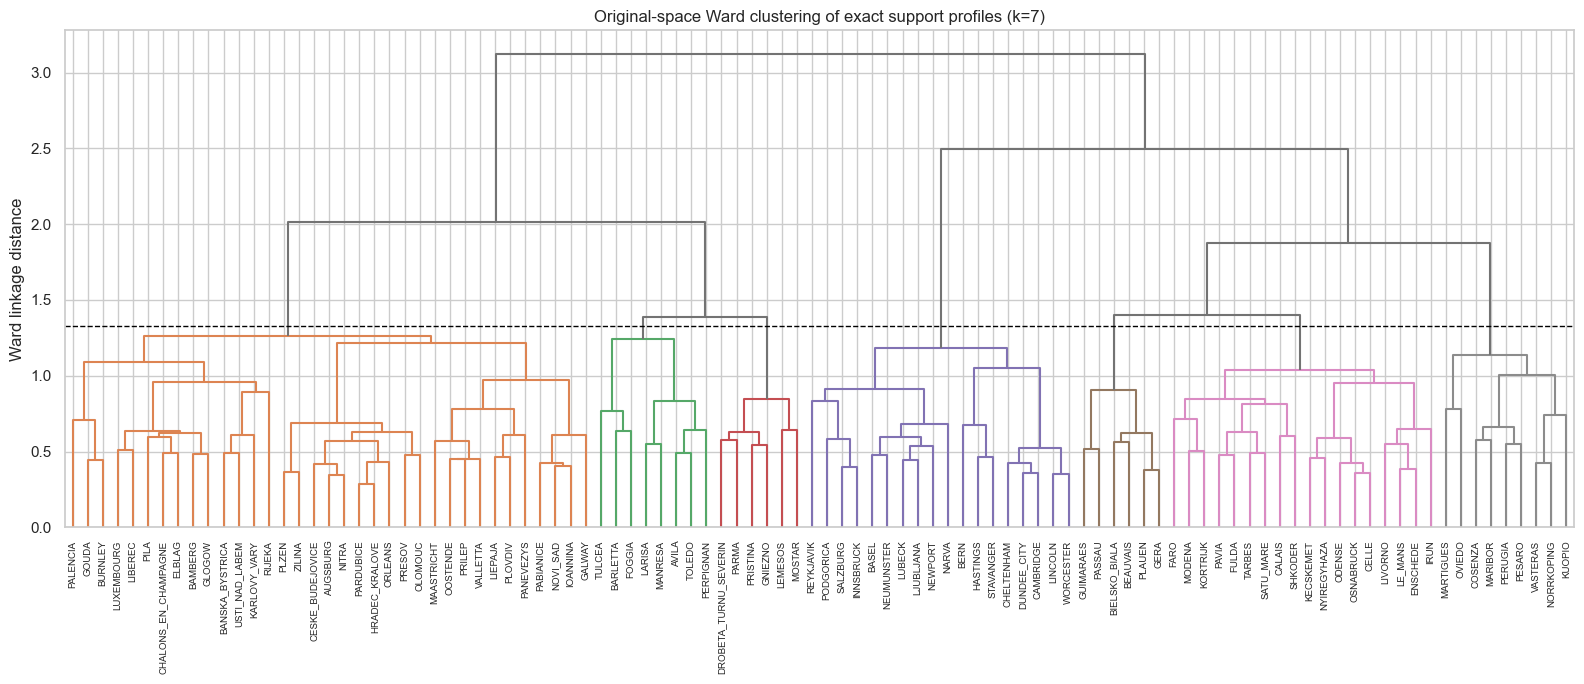

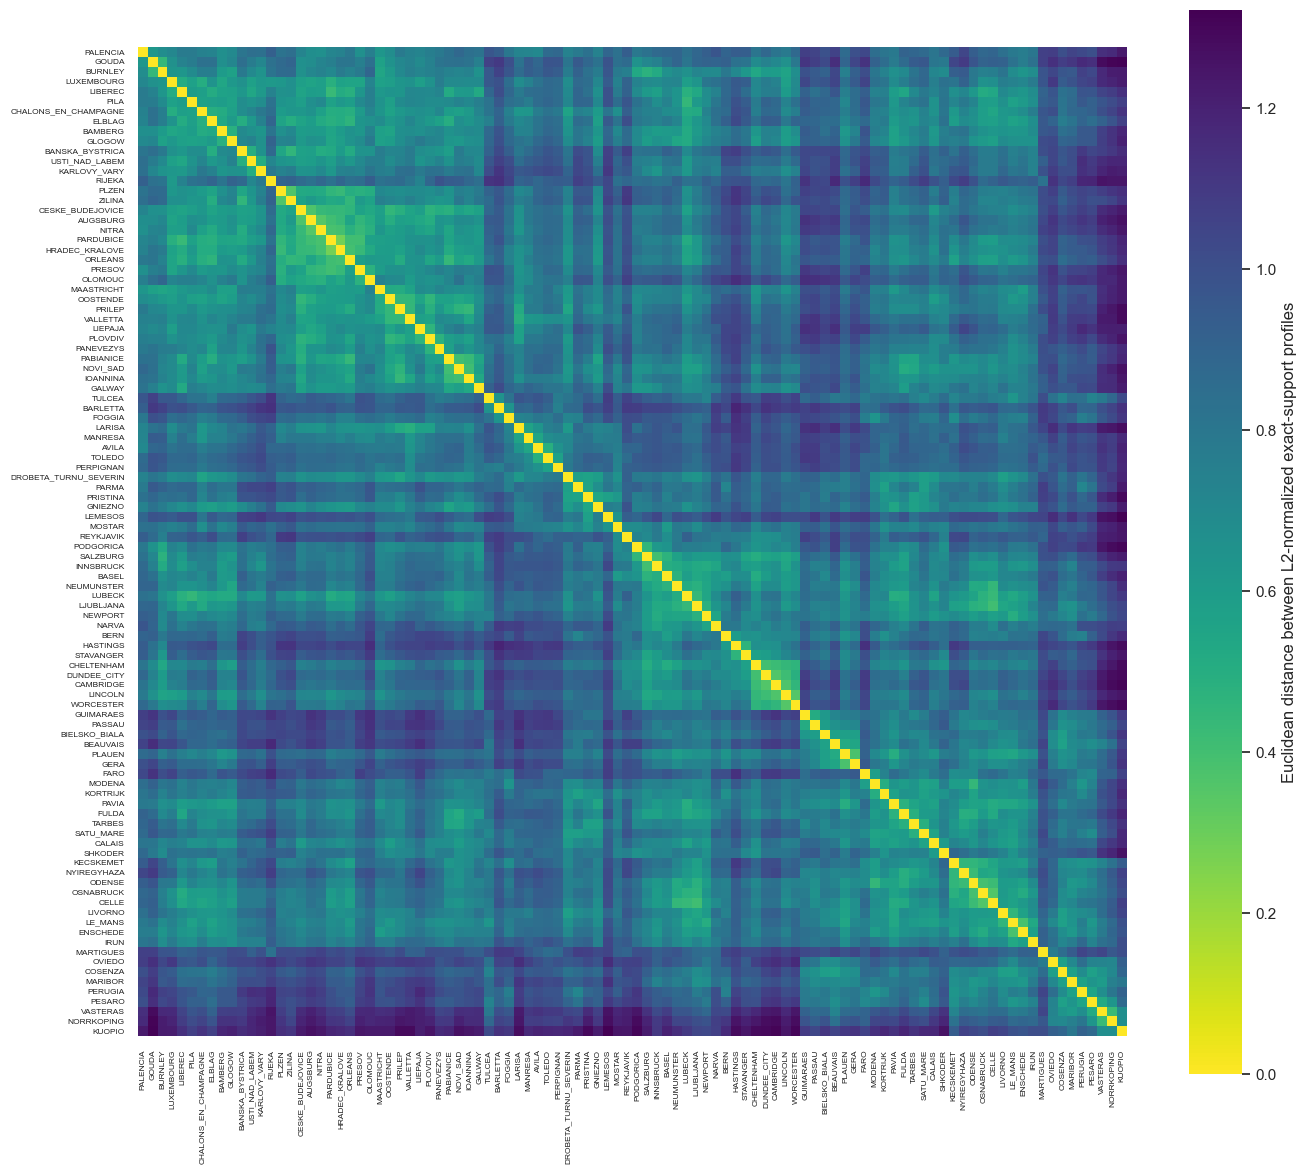

In [28]:
def distance_threshold_for_k(Z, k):
    heights = np.sort(Z[:, 2])
    n = len(heights) + 1
    return 0.5 * (heights[n - k - 1] + heights[n - k])


color_threshold = distance_threshold_for_k(primary_Z, PRIMARY_K)
palette = sns.color_palette("tab10", n_colors=PRIMARY_K)
cluster_colors = {
    cluster: palette[(cluster - 1) % len(palette)]
    for cluster in sorted(np.unique(primary_labels))
}

fig, ax = plt.subplots(figsize=(16, 7))
dendrogram(
    primary_Z,
    labels=main_matrix.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=7,
    color_threshold=color_threshold,
    above_threshold_color="0.45",
    ax=ax,
)
ax.axhline(color_threshold, color="black", linestyle="--", linewidth=1)
ax.set_ylabel("Ward linkage distance")
ax.set_xlabel("")
ax.set_title(f"Original-space Ward clustering of exact support profiles (k={PRIMARY_K})")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "primary_dendrogram.pdf", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "primary_dendrogram.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

primary_pairwise = pdist(primary_X, metric="euclidean")
primary_distance_matrix = squareform(primary_pairwise)
order = leaves_list(primary_Z)
ordered_names = main_matrix.index.to_numpy()[order]
ordered_distances = primary_distance_matrix[np.ix_(order, order)]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    ordered_distances,
    xticklabels=ordered_names,
    yticklabels=ordered_names,
    cmap="viridis_r",
    square=True,
    cbar_kws={"label": "Euclidean distance between L2-normalized exact-support profiles"},
    ax=ax,
)
ax.tick_params(axis="x", labelsize=6, rotation=90)
ax.tick_params(axis="y", labelsize=6, rotation=0)
ax.set_xlabel("")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "primary_distance_heatmap.pdf", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "primary_distance_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

## 4. Representation and clustering-geometry sensitivity

This section directly addresses the concern that converting neighborhoods to itemsets may discard dominance/intensity information.

- **Exact relative support** is the primary representation. It retains how often an itemset occurs across all focal-polygon transactions.
- **Rounded support** tests the integer percentages used in the legacy matrix.
- **Binary city-by-itemset presence** deliberately removes support magnitude and tests whether clusters depend on intensity.
- **Support counts** show that L2 normalization makes counts and relative supports mathematically equivalent within each city (counts are a row-wise scalar multiple of relative supports).
- **Unique-pattern support** gives each distinct transaction pattern one vote, deliberately removing repeated row multiplicity. Its disagreement with the primary result quantifies the contribution of repeated neighborhood occurrences.

None of these can restore duplicate same-type neighbors *within* a transaction, area, or boundary length; those require the missing polygon-level spatial join.

In [29]:
def cluster_ward(matrix, k=PRIMARY_K, row_normalization="l2"):
    X = prepare_features(matrix, row_normalization)
    Z = linkage(X, method="ward", metric="euclidean", optimal_ordering=True)
    return labels_at_k(Z, k), X, Z


def compare_partition(name, labels, X, silhouette_metric="euclidean", note=""):
    sizes = np.bincount(labels)[1:]
    distances = pdist(X, metric=silhouette_metric)
    return {
        "analysis": name,
        "ari_vs_primary": adjusted_rand_score(primary_labels_raw, labels),
        "nmi_vs_primary": normalized_mutual_info_score(primary_labels_raw, labels),
        "pairwise_distance_spearman_vs_primary": spearmanr(primary_pairwise, distances).statistic,
        "silhouette": silhouette_score(X, labels, metric=silhouette_metric),
        "minimum_cluster_size": int(sizes.min()),
        "maximum_cluster_size": int(sizes.max()),
        "note": note,
    }


representation_rows = [
    compare_partition(
        "Primary: exact relative support, L2 rows, Ward",
        primary_labels_raw,
        primary_X,
        note="Original city-by-itemset feature space",
    )
]

if saved_rounded_matrix is not None:
    rounded_matrix = saved_rounded_matrix.loc[city_order]
    rounded_labels, rounded_X, _ = cluster_ward(rounded_matrix)
    representation_rows.append(
        compare_partition(
            "Saved integer-percent supports, L2 rows, Ward",
            rounded_labels,
            rounded_X,
            note="Tests rounding in the legacy 1,543-column matrix",
        )
    )

binary_matrix = (main_matrix > 0).astype(float)
binary_labels, binary_X, _ = cluster_ward(binary_matrix)
representation_rows.append(
    compare_partition(
        "Binary frequent-itemset presence, L2 rows, Ward",
        binary_labels,
        binary_X,
        note="Removes support magnitude across focal polygons",
    )
)

count_matrix = count_matrices[MAIN_SUPPORT_THRESHOLD]
count_labels, count_X, _ = cluster_ward(count_matrix)
representation_rows.append(
    compare_partition(
        "Absolute support counts, L2 rows, Ward",
        count_labels,
        count_X,
        note="Equivalent to relative support after row-wise L2 normalization",
    )
)

raw_support_X = prepare_features(main_matrix, None)
raw_support_Z = linkage(raw_support_X, method="ward", metric="euclidean")
raw_support_labels = labels_at_k(raw_support_Z, PRIMARY_K)
representation_rows.append(
    compare_partition(
        "Exact relative support without row normalization, Ward",
        raw_support_labels,
        raw_support_X,
        note="Tests the row-normalization assumption",
    )
)

cosine_distances = pdist(raw_support_X, metric="cosine")
cosine_Z = linkage(cosine_distances, method="average", optimal_ordering=True)
cosine_labels = labels_at_k(cosine_Z, PRIMARY_K)
representation_rows.append(
    compare_partition(
        "Exact support, cosine distance, average linkage",
        cosine_labels,
        raw_support_X,
        silhouette_metric="cosine",
        note="Ward is not valid for cosine distance",
    )
)

for retained_variance in [0.90, 0.95]:
    pca = PCA(n_components=retained_variance, svd_solver="full")
    pca_X = pca.fit_transform(primary_X)
    pca_Z = linkage(pca_X, method="ward", metric="euclidean")
    pca_labels = labels_at_k(pca_Z, PRIMARY_K)
    representation_rows.append(
        compare_partition(
            f"PCA {retained_variance:.0%} + Ward",
            pca_labels,
            pca_X,
            note=f"{pca_X.shape[1]} components retained",
        )
    )

no_road_columns = [
    column for column in main_matrix.columns if "12220" not in column.split()
]
no_road_labels, no_road_X, _ = cluster_ward(main_matrix[no_road_columns])
representation_rows.append(
    compare_partition(
        "Exclude all itemsets containing other-roads code 12220",
        no_road_labels,
        no_road_X,
        note=f"Uses {len(no_road_columns)} of {main_matrix.shape[1]} features",
    )
)

ARTIFICIAL_CODES = {code for code in all_observed_codes if code.startswith("1")}
NON_ARTIFICIAL_CODES = set(all_observed_codes) - ARTIFICIAL_CODES
artificial_only_columns = [
    column
    for column in main_matrix.columns
    if set(column.split()).issubset(ARTIFICIAL_CODES)
]
artificial_only_labels, artificial_only_X, _ = cluster_ward(
    main_matrix[artificial_only_columns]
)
representation_rows.append(
    compare_partition(
        "Artificial-only itemsets, excluding every rural/natural code",
        artificial_only_labels,
        artificial_only_X,
        note=f"Uses {len(artificial_only_columns)} of {main_matrix.shape[1]} features",
    )
)

In [30]:
# Re-mine after collapsing repeated transaction rows within each city.
unique_pattern_support_counts = {
    city: mine_frequent_itemsets(
        sorted(set(transactions[city])), MAIN_SUPPORT_THRESHOLD
    )
    for city in city_order
}
unique_pattern_features = sorted(
    set().union(*(set(city_map) for city_map in unique_pattern_support_counts.values())),
    key=itemset_sort_key,
)
unique_pattern_matrix = pd.DataFrame(
    [
        [
            unique_pattern_support_counts[city].get(feature, 0)
            / len(set(transactions[city]))
            for feature in unique_pattern_features
        ]
        for city in city_order
    ],
    index=city_order,
    columns=[itemset_name(feature) for feature in unique_pattern_features],
)
unique_pattern_labels, unique_pattern_X, _ = cluster_ward(unique_pattern_matrix)
representation_rows.append(
    compare_partition(
        "One vote per unique transaction pattern, L2 rows, Ward",
        unique_pattern_labels,
        unique_pattern_X,
        note=(
            f"Deliberately removes {transaction_audit['repeated_transaction_occurrences'].sum():,} "
            "repeated focal-neighborhood occurrences"
        ),
    )
)

representation_comparison = pd.DataFrame(representation_rows)
representation_comparison.to_csv(
    OUTPUT_DIR / "representation_and_geometry_sensitivity.csv", index=False
)
display(
    representation_comparison[
        [
            "analysis", "ari_vs_primary", "nmi_vs_primary",
            "pairwise_distance_spearman_vs_primary", "silhouette",
            "minimum_cluster_size", "note",
        ]
    ].round(3)
)

equivalence_audit = pd.DataFrame(
    [
        {
            "quantity": "Maximum absolute difference: L2 exact-relative versus L2 absolute-count rows",
            "value": float(np.max(np.abs(primary_X - count_X))),
        },
        {
            "quantity": "Total raw transaction rows",
            "value": int(transaction_audit["transactions"].sum()),
        },
        {
            "quantity": "Total distinct transaction patterns within cities",
            "value": int(transaction_audit["unique_transaction_patterns"].sum()),
        },
        {
            "quantity": "Repeated transaction occurrences retained by standard support",
            "value": int(transaction_audit["repeated_transaction_occurrences"].sum()),
        },
        {
            "quantity": "Duplicate codes within rows available for weighting",
            "value": int(transaction_audit["duplicate_codes_within_rows"].sum()),
        },
    ]
)
equivalence_audit.to_csv(
    OUTPUT_DIR / "transaction_multiplicity_audit.csv", index=False
)
display(equivalence_audit)

,analysis,ari_vs_primary,nmi_vs_primary,pairwise_distance_spearman_vs_primary,silhouette,minimum_cluster_size,note
0,"Primary: exact relative support, L2 rows, Ward",1.000,1.000,1.000,0.121,6,Original city-by-itemset feature space
1,"Saved integer-percent supports, L2 rows, Ward",0.968,0.976,1.000,0.120,6,"Tests rounding in the legacy 1,543-column matrix"
2,"Binary frequent-itemset presence, L2 rows, Ward",0.286,0.572,0.937,0.063,6,Removes support magnitude across focal polygons
3,"Absolute support counts, L2 rows, Ward",1.000,1.000,1.000,0.121,6,Equivalent to relative support after row-wise ...
4,Exact relative support without row normalizati...,0.860,0.869,0.876,0.122,2,Tests the row-normalization assumption
5,"Exact support, cosine distance, average linkage",0.502,0.644,1.000,0.171,1,Ward is not valid for cosine distance
6,PCA 90% + Ward,0.819,0.838,0.999,0.153,6,31 components retained
7,PCA 95% + Ward,0.842,0.838,1.000,0.145,6,49 components retained
8,Exclude all itemsets containing other-roads co...,0.748,0.784,0.997,0.120,5,Uses 782 of 1543 features
9,"Artificial-only itemsets, excluding every rura...",0.291,0.499,0.826,0.144,3,Uses 444 of 1543 features


,quantity,value
0,Maximum absolute difference: L2 exact-relative...,2.775558e-16
1,Total raw transaction rows,2.903960e+05
2,Total distinct transaction patterns within cities,8.659100e+04
3,Repeated transaction occurrences retained by s...,2.038050e+05
4,Duplicate codes within rows available for weig...,0.000000e+00


## 5. Exact support-threshold sensitivity

Unlike the old notebook, this analysis does not threshold integer-rounded Excel percentages. Every threshold is applied to exact integer support counts re-mined from the 290,396 transaction rows. Each threshold is compared with the 10% primary partition at fixed `k=7`; a separately ranked candidate `k` is also reported so threshold and cluster-count assumptions are not conflated.

,support_threshold_percent,union_itemsets,matrix_density,independently_ranked_k,fixed_k,ari_vs_10_percent,nmi_vs_10_percent,pairwise_distance_spearman_vs_10_percent,minimum_cluster_size,maximum_cluster_size
0,5.0,4202,0.109,4,7,0.433,0.629,0.989,5,27
1,7.5,2370,0.113,3,7,0.810,0.797,0.995,3,36
2,10.0,1543,0.116,3,7,1.000,1.000,1.000,6,35
3,12.5,1087,0.118,7,7,0.911,0.925,0.995,6,35
4,15.0,801,0.122,2,7,0.591,0.720,0.987,3,31


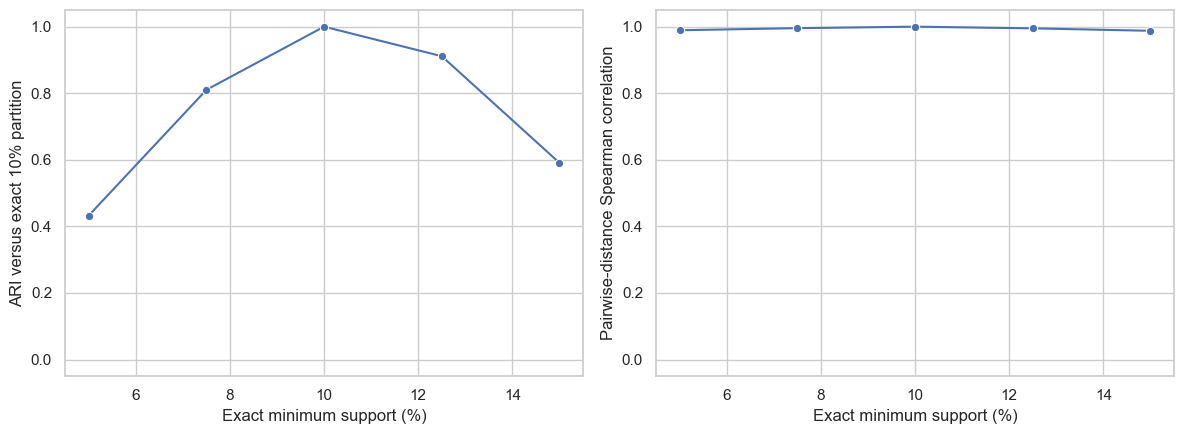

In [31]:
def rank_k_without_bootstrap(matrix, k_values):
    X = prepare_features(matrix, "l2")
    Z = linkage(X, method="ward", metric="euclidean", optimal_ordering=True)
    rows = []
    for k in k_values:
        labels = labels_at_k(Z, k)
        sizes = np.bincount(labels)[1:]
        rows.append(
            {
                "k": k,
                "silhouette": silhouette_score(X, labels),
                "calinski_harabasz": calinski_harabasz_score(X, labels),
                "davies_bouldin": davies_bouldin_score(X, labels),
                "minimum_cluster_size": int(sizes.min()),
            }
        )
    scores = pd.DataFrame(rows)
    scores["rank_silhouette"] = scores["silhouette"].rank(ascending=False)
    scores["rank_calinski_harabasz"] = scores["calinski_harabasz"].rank(ascending=False)
    scores["rank_davies_bouldin"] = scores["davies_bouldin"].rank(ascending=True)
    scores["mean_quality_rank"] = scores[
        ["rank_silhouette", "rank_calinski_harabasz", "rank_davies_bouldin"]
    ].mean(axis=1)
    eligible = scores[scores["minimum_cluster_size"] >= minimum_acceptable_size]
    best_k = int(eligible.sort_values(["mean_quality_rank", "k"]).iloc[0]["k"])
    return scores, best_k, Z, X


threshold_rows = []
threshold_city_labels = pd.DataFrame({"city": city_order})
for threshold in SUPPORT_THRESHOLDS:
    matrix = exact_matrices[threshold]
    scores, ranked_k, Z, X = rank_k_without_bootstrap(matrix, K_VALUES)
    labels = labels_at_k(Z, PRIMARY_K)
    threshold_city_labels[f"support_{threshold:g}_cluster"] = relabel_by_dendrogram(labels, Z)
    sizes = np.bincount(labels)[1:]
    threshold_rows.append(
        {
            "support_threshold_percent": threshold,
            "union_itemsets": matrix.shape[1],
            "matrix_density": np.count_nonzero(matrix.to_numpy()) / matrix.size,
            "independently_ranked_k": ranked_k,
            "fixed_k": PRIMARY_K,
            "ari_vs_10_percent": adjusted_rand_score(primary_labels_raw, labels),
            "nmi_vs_10_percent": normalized_mutual_info_score(primary_labels_raw, labels),
            "pairwise_distance_spearman_vs_10_percent": spearmanr(
                primary_pairwise, pdist(X, metric="euclidean")
            ).statistic,
            "minimum_cluster_size": int(sizes.min()),
            "maximum_cluster_size": int(sizes.max()),
        }
    )
    scores.to_csv(
        OUTPUT_DIR / f"k_quality_exact_support_{threshold:g}_percent.csv",
        index=False,
    )

threshold_sensitivity = pd.DataFrame(threshold_rows)
threshold_sensitivity.to_csv(
    OUTPUT_DIR / "exact_support_threshold_sensitivity.csv", index=False
)
threshold_city_labels.to_csv(
    OUTPUT_DIR / "exact_support_threshold_city_labels.csv", index=False
)
display(threshold_sensitivity.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.lineplot(
    data=threshold_sensitivity,
    x="support_threshold_percent",
    y="ari_vs_10_percent",
    marker="o",
    ax=axes[0],
)
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_ylabel("ARI versus exact 10% partition")
axes[0].set_xlabel("Exact minimum support (%)")
sns.lineplot(
    data=threshold_sensitivity,
    x="support_threshold_percent",
    y="pairwise_distance_spearman_vs_10_percent",
    marker="o",
    ax=axes[1],
)
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_ylabel("Pairwise-distance Spearman correlation")
axes[1].set_xlabel("Exact minimum support (%)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "exact_support_threshold_sensitivity.pdf", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "exact_support_threshold_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

## 6. UMAP parameter and random-seed sensitivity

UMAP is **not** used to define the primary groups. The 54-run grid is a visualization/diagnostic sensitivity analysis only.

v3 corrects the k-nearest-neighbor overlap calculation. The helper explicitly queries the fitted high- and low-dimensional data matrices, removes each observation's own index by identity, and retains the nearest 10 *other* observations. This avoids the v2 off-by-one behavior that evaluated neighbors ranked 2–11.

Because UMAP results can vary across library versions and platforms, the closest reproduction should use the final-run environment recorded in `requirements_v3.txt`. The notebook records the actual environment used for every fresh run and compares key UMAP tables with the included manuscript reference outputs.


In [32]:
try:
    import umap
    UMAP_AVAILABLE = True
    print("umap-learn version:", getattr(umap, "__version__", "unknown"))
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP diagnostics skipped: install umap-learn and rerun Sections 6 and 11.")


def nearest_other_indices(X, n_neighbors=10, metric="euclidean"):
    """Return the nearest n_neighbors observations other than each row itself.

    An explicit query matrix is used so behavior does not depend on scikit-learn's
    special X=None handling. The observation's own index is removed by identity,
    not by assuming it occupies a particular rank under possible zero-distance ties.
    """
    X = np.asarray(X)
    if len(X) < 2:
        raise ValueError("At least two observations are required.")
    n_neighbors = min(int(n_neighbors), len(X) - 1)
    query_count = min(n_neighbors + 1, len(X))
    raw = NearestNeighbors(n_neighbors=query_count, metric=metric).fit(X).kneighbors(
        X, return_distance=False
    )
    cleaned = []
    for i, row in enumerate(raw):
        candidates = [int(j) for j in row if int(j) != i]
        if len(candidates) < n_neighbors:
            # Extremely degenerate tie handling fallback: request all observations.
            all_row = NearestNeighbors(n_neighbors=len(X), metric=metric).fit(X).kneighbors(
                X[i : i + 1], return_distance=False
            )[0]
            candidates = [int(j) for j in all_row if int(j) != i]
        cleaned.append(candidates[:n_neighbors])
    return np.asarray(cleaned, dtype=int)


def mean_knn_overlap(X_high, X_low, n_neighbors=10, high_metric="euclidean"):
    n_neighbors = min(int(n_neighbors), len(X_high) - 1)
    high_indices = nearest_other_indices(
        X_high, n_neighbors=n_neighbors, metric=high_metric
    )
    low_indices = nearest_other_indices(
        X_low, n_neighbors=n_neighbors, metric="euclidean"
    )
    overlaps = [
        len(set(high_indices[i]).intersection(low_indices[i])) / n_neighbors
        for i in range(len(X_high))
    ]
    return float(np.mean(overlaps))


umap-learn version: 0.5.7


In [33]:
umap_rows = []
umap_embeddings = {}
umap_diagnostic_labels = {}

if UMAP_AVAILABLE:
    for n_neighbors, min_dist, metric, seed in itertools.product(
        UMAP_NEIGHBORS, UMAP_MIN_DIST, UMAP_METRICS, UMAP_SEEDS
    ):
        key = (n_neighbors, min_dist, metric, seed)
        model = umap.UMAP(
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            n_components=2,
            metric=metric,
            random_state=seed,
            n_jobs=1,
            low_memory=True,
        )
        embedding = model.fit_transform(primary_X)
        embedding_Z = linkage(embedding, method="ward", metric="euclidean")
        embedding_labels = labels_at_k(embedding_Z, PRIMARY_K)
        high_distances = pdist(primary_X, metric=metric)
        low_distances = pdist(embedding, metric="euclidean")
        umap_embeddings[key] = embedding
        umap_diagnostic_labels[key] = embedding_labels
        umap_rows.append(
            {
                "n_neighbors": n_neighbors,
                "min_dist": min_dist,
                "metric": metric,
                "seed": seed,
                "trustworthiness_k10": trustworthiness(
                    primary_X, embedding, n_neighbors=10, metric=metric
                ),
                "knn_overlap_k10": mean_knn_overlap(
                    primary_X, embedding, n_neighbors=10, high_metric=metric
                ),
                "distance_spearman": spearmanr(high_distances, low_distances).statistic,
                "ari_2d_vs_primary": adjusted_rand_score(
                    primary_labels_raw, embedding_labels
                ),
                "nmi_2d_vs_primary": normalized_mutual_info_score(
                    primary_labels_raw, embedding_labels
                ),
            }
        )

    umap_runs = pd.DataFrame(umap_rows)
    seed_rows = []
    for parameters, group in umap_runs.groupby(["n_neighbors", "min_dist", "metric"]):
        keys = [
            (int(row.n_neighbors), float(row.min_dist), row.metric, int(row.seed))
            for row in group.itertuples()
        ]
        aris = [
            adjusted_rand_score(
                umap_diagnostic_labels[key_a], umap_diagnostic_labels[key_b]
            )
            for key_a, key_b in itertools.combinations(keys, 2)
        ]
        seed_rows.append(
            {
                "n_neighbors": parameters[0],
                "min_dist": parameters[1],
                "metric": parameters[2],
                "seed_stability_ari_mean": float(np.mean(aris)),
                "seed_stability_ari_min": float(np.min(aris)),
            }
        )
    seed_stability = pd.DataFrame(seed_rows)
    umap_summary = (
        umap_runs.groupby(["n_neighbors", "min_dist", "metric"], as_index=False)
        .agg(
            trustworthiness_mean=("trustworthiness_k10", "mean"),
            knn_overlap_mean=("knn_overlap_k10", "mean"),
            distance_spearman_mean=("distance_spearman", "mean"),
            ari_2d_vs_primary_mean=("ari_2d_vs_primary", "mean"),
            ari_2d_vs_primary_min=("ari_2d_vs_primary", "min"),
        )
        .merge(seed_stability, on=["n_neighbors", "min_dist", "metric"])
        .sort_values(["metric", "n_neighbors", "min_dist"])
    )
    umap_overall_ranges = pd.DataFrame(
        [
            {
                "metric": column,
                "minimum": float(umap_runs[column].min()),
                "maximum": float(umap_runs[column].max()),
            }
            for column in [
                "trustworthiness_k10",
                "knn_overlap_k10",
                "distance_spearman",
                "ari_2d_vs_primary",
                "nmi_2d_vs_primary",
            ]
        ]
    )
    umap_runs.to_csv(OUTPUT_DIR / "umap_all_54_runs.csv", index=False)
    umap_summary.to_csv(OUTPUT_DIR / "umap_parameter_seed_summary.csv", index=False)
    umap_overall_ranges.to_csv(OUTPUT_DIR / "umap_overall_diagnostic_ranges.csv", index=False)
    display(umap_summary.round(3))
    display(umap_overall_ranges.round(3))
    overlap_row = umap_overall_ranges.set_index("metric").loc["knn_overlap_k10"]
    print(
        "Corrected nearest-10 UMAP overlap range:",
        f"{overlap_row['minimum']:.3f}–{overlap_row['maximum']:.3f}",
    )
else:
    umap_runs = pd.DataFrame()
    umap_summary = pd.DataFrame()
    umap_overall_ranges = pd.DataFrame()


c:\Users\it08d\.conda\envs\2026\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\it08d\.conda\envs\2026\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\it08d\.conda\envs\2026\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\it08d\.conda\envs\2026\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\it08d\.conda\envs\2026\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed 

,n_neighbors,min_dist,metric,trustworthiness_mean,knn_overlap_mean,distance_spearman_mean,ari_2d_vs_primary_mean,ari_2d_vs_primary_min,seed_stability_ari_mean,seed_stability_ari_min
0,5,0.0,cosine,0.885,0.544,0.590,0.488,0.472,0.835,0.751
2,5,0.1,cosine,0.888,0.560,0.610,0.501,0.474,0.687,0.615
4,5,0.5,cosine,0.887,0.557,0.626,0.457,0.397,0.623,0.602
6,15,0.0,cosine,0.907,0.586,0.644,0.516,0.465,0.647,0.576
8,15,0.1,cosine,0.907,0.590,0.637,0.471,0.393,0.690,0.618
10,15,0.5,cosine,0.906,0.581,0.709,0.455,0.419,0.536,0.472
12,30,0.0,cosine,0.907,0.588,0.677,0.470,0.387,0.639,0.585
14,30,0.1,cosine,0.907,0.581,0.676,0.486,0.433,0.541,0.482
16,30,0.5,cosine,0.904,0.569,0.712,0.492,0.441,0.512,0.458
1,5,0.0,euclidean,0.867,0.530,0.568,0.492,0.433,0.724,0.587


,metric,minimum,maximum
0,trustworthiness_k10,0.854,0.914
1,knn_overlap_k10,0.516,0.597
2,distance_spearman,0.520,0.731
3,ari_2d_vs_primary,0.342,0.612
4,nmi_2d_vs_primary,0.598,0.758


Corrected nearest-10 UMAP overlap range: 0.516–0.597


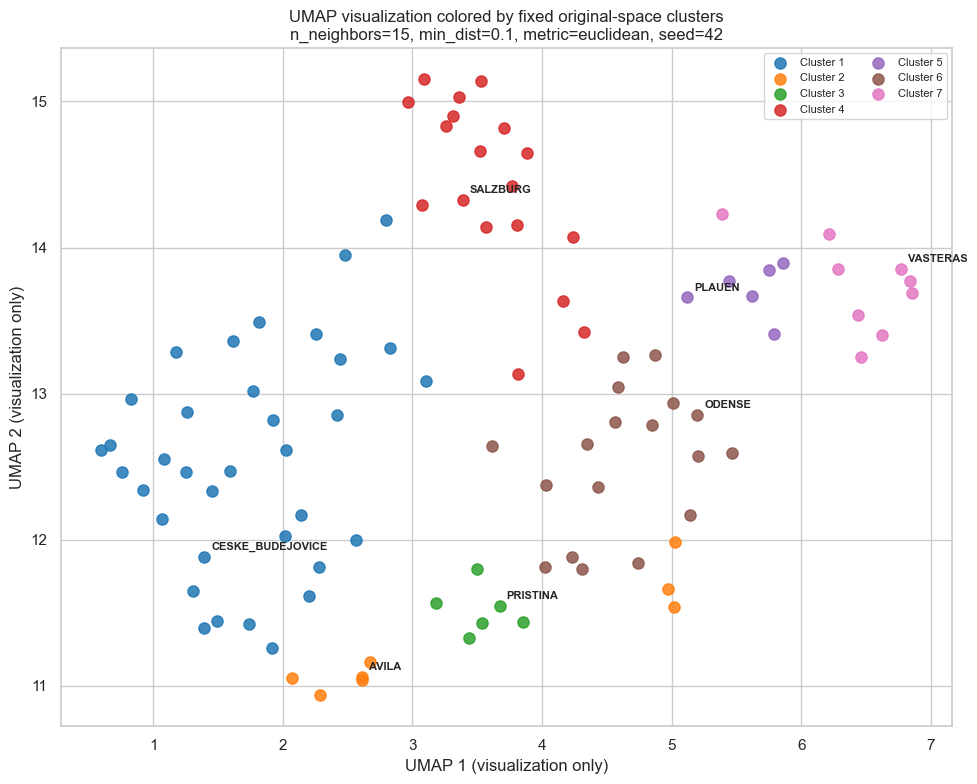

In [34]:
if UMAP_AVAILABLE:
    display_key = (15, 0.1, "euclidean", 42)
    display_embedding = umap_embeddings[display_key]
    fig, ax = plt.subplots(figsize=(10, 8))
    for cluster_id in sorted(np.unique(primary_labels)):
        mask = primary_labels == cluster_id
        ax.scatter(
            display_embedding[mask, 0],
            display_embedding[mask, 1],
            s=65,
            alpha=0.85,
            label=f"Cluster {cluster_id}",
            color=cluster_colors[cluster_id],
        )
        member_positions = np.where(mask)[0]
        within = squareform(pdist(primary_X[member_positions]))
        medoid_position = member_positions[np.argmin(within.sum(axis=1))]
        x, y = display_embedding[medoid_position]
        ax.annotate(
            main_matrix.index[medoid_position],
            (x, y),
            fontsize=8,
            fontweight="bold",
            xytext=(5, 5),
            textcoords="offset points",
        )
    ax.set_title(
        "UMAP visualization colored by fixed original-space clusters\n"
        "n_neighbors=15, min_dist=0.1, metric=euclidean, seed=42"
    )
    ax.set_xlabel("UMAP 1 (visualization only)")
    ax.set_ylabel("UMAP 2 (visualization only)")
    ax.legend(ncol=2, fontsize=8)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "umap_visualization_original_space_labels.pdf", bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / "umap_visualization_original_space_labels.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## 7. Rural/non-artificial influence and boundary-sensitive interpretation

Urban Atlas codes beginning with `1` are artificial surfaces; codes beginning with `2`–`5` are agricultural, natural, wetland, or water classes. The diagnostics below use transaction prevalence, **not land area**. They therefore answer whether rural/natural categories occur in many focal-polygon neighborhoods, not what proportion of the Core/FUA area is rural.

Three complementary checks are reported:

1. cluster profiles of transaction-level non-artificial prevalence;
2. agreement after excluding every itemset containing a non-artificial code; and
3. correlation between full-space city distance and the absolute difference in non-artificial transaction prevalence.

**Inference warning.** The Kruskal–Wallis comparisons across the seven clusters use rural/non-artificial metrics derived from the **same transaction data that generated the clusters**. Their `p`-values are therefore reported only as exploratory/descriptive summaries of separation within the discovered partition, not as independent confirmatory tests. The artificial-only re-clustering ARI is the stronger sensitivity result for assessing how much non-artificial content influences the grouping.


share_transactions_with_nonartificial                       \
                                         mean median    min    max   
cluster                                                              
1                                       0.646  0.659  0.381  0.850   
2                                       0.769  0.785  0.573  0.822   
3                                       0.694  0.680  0.570  0.835   
4                                       0.587  0.617  0.278  0.794   
5                                       0.847  0.831  0.750  0.982   
6                                       0.755  0.769  0.542  0.922   
7                                       0.905  0.900  0.812  0.986   

        share_transactions_nonartificial_only                       \
                                         mean median    min    max   
cluster                                                              
1                                       0.015  0.009  0.000  0.074   
2                                       0.056  0.033  0.004  0.171   
3                                       0.012  0.004  0.001  0.045   
4                                       0.011  0.008  0.002  0.045   
5                                       0.024  0.022  0.002  0.047   
6                                       0.026  0.020  0.001  0.093   
7                                       0.055  0.015  0.007  0.154   

        mean_nonartificial_types_per_transaction                       
                                            mean median    min    max  
cluster                                                                
1                                          1.275  1.324  0.667  1.833  
2                                          1.651  1.663  0.807  2.286  
3                                          1.257  1.228  0.932  1.642  
4                                          1.112  1.047  0.508  1.653  
5                                          2.030  2.040  1.630  2.440  
6                                          1.630  1.564  1.014  2.069  
7                                          2.284  2.204  1.944  2.830

,metric,kruskal_h,p_value,eta_squared_descriptive,interpretation_scope,holm_adjusted_p
2,mean_nonartificial_types_per_transaction,51.9907,0.0000,0.5656,Exploratory/descriptive only: metric and clust...,0.0000
0,share_transactions_with_nonartificial,50.0341,0.0000,0.4548,Exploratory/descriptive only: metric and clust...,0.0000
1,share_transactions_nonartificial_only,15.0688,0.0197,0.2235,Exploratory/descriptive only: metric and clust...,0.0197


ARI: full itemsets versus artificial-only itemsets: 0.291
Spearman(full distance, rural-prevalence difference): 0.325
Spearman(full distance, artificial-only distance): 0.826


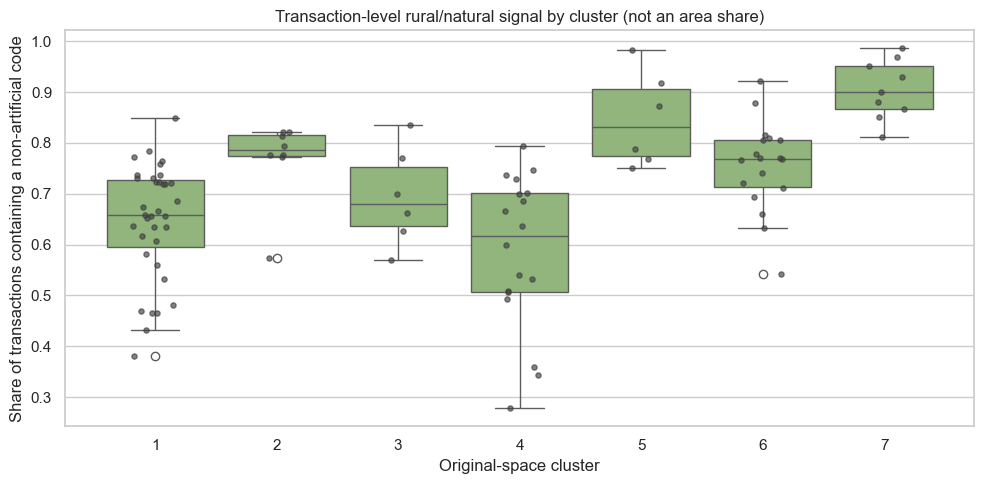

In [35]:
rural_rows = []
for city in city_order:
    rows = transactions[city]
    nonartificial_counts = np.array(
        [len(set(row).intersection(NON_ARTIFICIAL_CODES)) for row in rows]
    )
    artificial_counts = np.array(
        [len(set(row).intersection(ARTIFICIAL_CODES)) for row in rows]
    )
    rural_rows.append(
        {
            "city": city,
            "share_transactions_with_nonartificial": float(np.mean(nonartificial_counts > 0)),
            "share_transactions_artificial_only": float(np.mean(nonartificial_counts == 0)),
            "share_transactions_nonartificial_only": float(np.mean(artificial_counts == 0)),
            "mean_nonartificial_types_per_transaction": float(np.mean(nonartificial_counts)),
            "median_nonartificial_types_per_transaction": float(np.median(nonartificial_counts)),
            "mean_transaction_length": float(np.mean([len(row) for row in rows])),
        }
    )
rural_diagnostics = pd.DataFrame(rural_rows).merge(
    primary_assignments[["city", "cluster", "country_code"]],
    on="city",
    how="left",
)
rural_diagnostics.to_csv(
    OUTPUT_DIR / "city_transaction_level_rural_diagnostics.csv", index=False
)

rural_metrics = [
    "share_transactions_with_nonartificial",
    "share_transactions_nonartificial_only",
    "mean_nonartificial_types_per_transaction",
]
association_rows = []
for metric in rural_metrics:
    groups = [
        group[metric].to_numpy()
        for _, group in rural_diagnostics.groupby("cluster")
    ]
    statistic, p_value = kruskal(*groups)
    grand_mean = rural_diagnostics[metric].mean()
    between = sum(
        len(group) * (group[metric].mean() - grand_mean) ** 2
        for _, group in rural_diagnostics.groupby("cluster")
    )
    total = ((rural_diagnostics[metric] - grand_mean) ** 2).sum()
    association_rows.append(
        {
            "metric": metric,
            "kruskal_h": statistic,
            "p_value": p_value,
            "eta_squared_descriptive": between / total if total else np.nan,
        }
    )
rural_associations = pd.DataFrame(association_rows).sort_values("p_value")
rural_associations["interpretation_scope"] = (
    "Exploratory/descriptive only: metric and cluster labels derive from the same transaction dataset"
)
m = len(rural_associations)
rural_associations["holm_adjusted_p"] = np.maximum.accumulate(
    np.minimum(1.0, rural_associations["p_value"].to_numpy() * np.arange(m, 0, -1))
)

rural_cluster_profiles = rural_diagnostics.groupby("cluster")[rural_metrics].agg(
    ["mean", "median", "min", "max"]
)
rural_cluster_profiles.to_csv(
    OUTPUT_DIR / "cluster_transaction_level_rural_profiles.csv"
)
rural_associations.to_csv(
    OUTPUT_DIR / "rural_metric_cluster_associations.csv", index=False
)

rural_difference = pdist(
    rural_diagnostics.set_index("city").loc[city_order, ["share_transactions_with_nonartificial"]],
    metric="cityblock",
)
rural_distance_rho = spearmanr(primary_pairwise, rural_difference).statistic
artificial_distance_rho = spearmanr(
    primary_pairwise, pdist(artificial_only_X, metric="euclidean")
).statistic

display(rural_cluster_profiles.round(3))
display(rural_associations.round(4))
print("ARI: full itemsets versus artificial-only itemsets:", round(adjusted_rand_score(primary_labels_raw, artificial_only_labels), 3))
print("Spearman(full distance, rural-prevalence difference):", round(rural_distance_rho, 3))
print("Spearman(full distance, artificial-only distance):", round(artificial_distance_rho, 3))

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=rural_diagnostics,
    x="cluster",
    y="share_transactions_with_nonartificial",
    color="#8fbf72",
    ax=ax,
)
cluster_order = sorted(rural_diagnostics["cluster"].unique())
cluster_position = {cluster_id: i for i, cluster_id in enumerate(cluster_order)}
jitter_rng = np.random.default_rng(RANDOM_SEED)
jitter_x = np.array(
    [cluster_position[int(cluster_id)] for cluster_id in rural_diagnostics["cluster"]],
    dtype=float,
) + jitter_rng.uniform(-0.18, 0.18, size=len(rural_diagnostics))
ax.scatter(
    jitter_x,
    rural_diagnostics["share_transactions_with_nonartificial"].to_numpy(),
    s=14,
    color="0.25",
    alpha=0.65,
    zorder=3,
)
ax.set_xlabel("Original-space cluster")
ax.set_ylabel("Share of transactions containing a non-artificial code")
ax.set_title("Transaction-level rural/natural signal by cluster (not an area share)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "transaction_rural_signal_by_cluster.pdf", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "transaction_rural_signal_by_cluster.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


## 8. Country composition as a planning hypothesis, not a causal explanation

The source filenames preserve two-letter country codes. Country concentration can flag where common national data definitions, legal systems, planning institutions, or development histories merit qualitative follow-up. It cannot establish which institution caused a land-use pattern, and it must not be presented as causal evidence.

Because many countries contribute few cities, the country-cluster association is calibrated by permutation rather than relying only on an asymptotic chi-square p-value.

In [36]:
def cramers_v(table):
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    denominator = min(table.shape[0] - 1, table.shape[1] - 1)
    return math.sqrt((chi2 / n) / denominator) if denominator > 0 else np.nan


country_cluster_table = pd.crosstab(
    primary_assignments["cluster"], primary_assignments["country_code"]
)
observed_country_v = cramers_v(country_cluster_table)
rng = np.random.default_rng(RANDOM_SEED)
permutation_values = []
country_values = primary_assignments["country_code"].to_numpy()
cluster_values = primary_assignments["cluster"].to_numpy()
for _ in range(5000):
    permuted = rng.permutation(country_values)
    permutation_values.append(
        cramers_v(pd.crosstab(cluster_values, permuted))
    )
country_permutation_p = (
    1 + np.sum(np.asarray(permutation_values) >= observed_country_v)
) / (len(permutation_values) + 1)

country_summary_rows = []
for cluster_id, group in primary_assignments.groupby("cluster"):
    counts = group["country_code"].value_counts()
    probabilities = counts / counts.sum()
    country_summary_rows.append(
        {
            "cluster": cluster_id,
            "cities": len(group),
            "countries": counts.size,
            "country_entropy": float(-(probabilities * np.log(probabilities)).sum()),
            "largest_country_share": float(probabilities.iloc[0]),
            "top_countries": "; ".join(
                f"{country}:{count}" for country, count in counts.head(5).items()
            ),
        }
    )
country_cluster_summary = pd.DataFrame(country_summary_rows)
country_cluster_table.to_csv(OUTPUT_DIR / "cluster_by_country_crosstab.csv")
country_cluster_summary.to_csv(
    OUTPUT_DIR / "cluster_country_composition.csv", index=False
)
country_association = pd.DataFrame(
    [
        {
            "measure": "Cramer's V",
            "value": observed_country_v,
            "permutations": len(permutation_values),
            "permutation_p_value": country_permutation_p,
            "interpretation": "Descriptive association only; sparse national samples and no institutional covariates",
        }
    ]
)
country_association.to_csv(
    OUTPUT_DIR / "country_cluster_permutation_association.csv", index=False
)
display(country_cluster_summary)
display(country_association.round(4))

,cluster,cities,countries,country_entropy,largest_country_share,top_countries
0,1,35,19,2.644355,0.228571,CZ:8; PL:4; SK:4; FR:2; DE:2
1,2,8,5,1.494175,0.375000,ES:3; IT:2; EL:1; FR:1; RO:1
2,3,6,6,1.791759,0.166667,RO:1; PL:1; CY:1; BA:1; IT:1
3,4,18,9,1.902580,0.388889,UK:7; CH:2; AT:2; DE:2; SI:1
4,5,6,4,1.242453,0.500000,DE:3; FR:1; PL:1; PT:1
5,6,18,11,2.264049,0.166667,FR:3; DE:3; IT:3; HU:2; NL:1
6,7,9,6,1.676988,0.333333,IT:3; SE:2; FI:1; SI:1; FR:1


,measure,value,permutations,permutation_p_value,interpretation
0,Cramer's V,0.6932,5000,0.0002,Descriptive association only; sparse national ...


## 9. Buffer and Core/FUA evidence: completed audit and honest limit

The public repository contains one set of 100-city transaction files and the corresponding saved negFIN outputs. It does **not** contain the original Urban Atlas polygon layers, polygon IDs, spatial-join tables, ArcGIS toolbox/geodatabase, or alternative-buffer transaction folders. Therefore, new 50/100/150/200 m analyses across heterogeneous cities and a paired Urban Core/full-FUA comparison cannot be reconstructed from these repository inputs alone.

The included thesis supplies a historical Olomouc calibration table (10–200 m) and documents use of official `_UrbanCore` extents. Those statements are documentary provenance, not substitutes for a new multi-city sensitivity analysis. The manuscript therefore:

- reports the historical buffer calibration as limited evidence rather than general validation;
- justifies 100 m as the selected local analytical scale rather than a universal optimum;
- identifies the one-specification design as a limitation;
- treats the study extent as Urban Core based on the documented workflow; and
- does not claim a Core/full-FUA robustness test.


,requested_input_or_test,available,evidence_or_limit
0,Raw one-row-per-focal-polygon transactions for...,True,"100 text files; 290,396 rows"
1,Exact support thresholds,True,Re-mined directly from transaction IDs at five...
2,Repeated transaction-pattern multiplicity,True,"203,805 repeated occurrences retained"
3,Within-neighborhood same-type neighbor multipl...,False,Duplicate codes were removed upstream; all par...
4,Polygon area or shared-boundary/contact weighting,False,"No polygon IDs, geometry, area, contact length..."
5,Alternative-buffer transaction outputs across ...,False,No alternative-buffer folder/file name found; ...
6,GIS source layer or ArcGIS toolbox,False,"The thesis lists external attachments, but the..."
7,Paired official Core and full-FUA data,False,Thesis documents Core clipping; no paired spat...


,buffer_m,mean_transaction_length,median_transaction_length,source,status
0,10,4.269231,4,"Novak thesis, Table 5; historical Olomouc expe...","documentary calibration, not rerun from the up..."
1,25,4.556490,4,"Novak thesis, Table 5; historical Olomouc expe...","documentary calibration, not rerun from the up..."
2,50,4.929087,5,"Novak thesis, Table 5; historical Olomouc expe...","documentary calibration, not rerun from the up..."
3,75,5.292067,5,"Novak thesis, Table 5; historical Olomouc expe...","documentary calibration, not rerun from the up..."
4,100,5.654447,5,"Novak thesis, Table 5; historical Olomouc expe...","documentary calibration, not rerun from the up..."
5,125,5.989183,6,"Novak thesis, Table 5; historical Olomouc expe...","documentary calibration, not rerun from the up..."
6,150,6.289062,6,"Novak thesis, Table 5; historical Olomouc expe...","documentary calibration, not rerun from the up..."
7,175,6.556490,6,"Novak thesis, Table 5; historical Olomouc expe...","documentary calibration, not rerun from the up..."
8,200,6.836538,7,"Novak thesis, Table 5; historical Olomouc expe...","documentary calibration, not rerun from the up..."


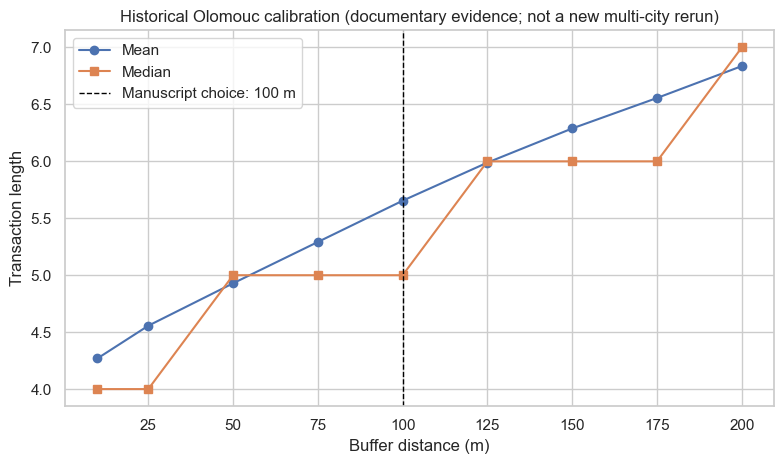

In [37]:
repository_member_lower = [
    path.relative_to(PROJECT_DIR).as_posix().lower()
    for path in PROJECT_DIR.rglob("*")
]
capability_rows = [
    {
        "requested_input_or_test": "Raw one-row-per-focal-polygon transactions for 100 cities",
        "available": True,
        "evidence_or_limit": f"{len(input_files)} text files; {transaction_audit['transactions'].sum():,} rows",
    },
    {
        "requested_input_or_test": "Exact support thresholds",
        "available": True,
        "evidence_or_limit": "Re-mined directly from transaction IDs at five thresholds",
    },
    {
        "requested_input_or_test": "Repeated transaction-pattern multiplicity",
        "available": True,
        "evidence_or_limit": f"{transaction_audit['repeated_transaction_occurrences'].sum():,} repeated occurrences retained",
    },
    {
        "requested_input_or_test": "Within-neighborhood same-type neighbor multiplicity",
        "available": False,
        "evidence_or_limit": "Duplicate codes were removed upstream; all parsed rows contain unique codes",
    },
    {
        "requested_input_or_test": "Polygon area or shared-boundary/contact weighting",
        "available": False,
        "evidence_or_limit": "No polygon IDs, geometry, area, contact length, orientation, or overlap extent",
    },
    {
        "requested_input_or_test": "Alternative-buffer transaction outputs across cities",
        "available": any(re.search(r"(?:^|[_/])(50|75|125|150|175|200|400)m(?:[_/.]|$)", member) for member in repository_member_lower),
        "evidence_or_limit": "No alternative-buffer folder/file name found; only historical thesis figure/table",
    },
    {
        "requested_input_or_test": "GIS source layer or ArcGIS toolbox",
        "available": any(member.endswith((".gdb", ".gpkg", ".shp", ".atbx", ".tbx")) for member in repository_member_lower),
        "evidence_or_limit": "The thesis lists external attachments, but they are not included in this public repository",
    },
    {
        "requested_input_or_test": "Paired official Core and full-FUA data",
        "available": False,
        "evidence_or_limit": "Thesis documents Core clipping; no paired spatial or transaction specifications",
    },
]
data_capability_audit = pd.DataFrame(capability_rows)
data_capability_audit.to_csv(
    OUTPUT_DIR / "data_capability_audit.csv", index=False
)

historical_buffer_calibration = pd.DataFrame(
    {
        "buffer_m": [10, 25, 50, 75, 100, 125, 150, 175, 200],
        "mean_transaction_length": [
            4.26923077, 4.55649038, 4.92908654, 5.29206731, 5.65444712,
            5.98918269, 6.28906250, 6.55649038, 6.83653846,
        ],
        "median_transaction_length": [4, 4, 5, 5, 5, 6, 6, 6, 7],
        "source": "Novak thesis, Table 5; historical Olomouc experiment",
        "status": "documentary calibration, not rerun from the public repository",
    }
)
historical_buffer_calibration.to_csv(
    OUTPUT_DIR / "historical_olomouc_buffer_calibration.csv", index=False
)
display(data_capability_audit)
display(historical_buffer_calibration)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(
    historical_buffer_calibration["buffer_m"],
    historical_buffer_calibration["mean_transaction_length"],
    marker="o",
    label="Mean",
)
ax.plot(
    historical_buffer_calibration["buffer_m"],
    historical_buffer_calibration["median_transaction_length"],
    marker="s",
    label="Median",
)
ax.axvline(100, color="black", linestyle="--", linewidth=1, label="Manuscript choice: 100 m")
ax.set_xlabel("Buffer distance (m)")
ax.set_ylabel("Transaction length")
ax.set_title("Historical Olomouc calibration (documentary evidence; not a new multi-city rerun)")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "historical_olomouc_buffer_calibration.pdf", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "historical_olomouc_buffer_calibration.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


## 10. Integrated planning-facing cluster profiles

These summaries are intended to support revision of the Results and Discussion. They describe—not explain—each cluster using its medoid city, characteristic co-occurrences, transaction-level rural signal, and country composition. Institutional or regulatory explanations must be supported by external planning evidence and should be framed as tested interpretations or hypotheses, not inferred automatically from the clustering.

In [38]:
planning_profile_rows = []
rural_indexed = rural_diagnostics.set_index("city")
country_indexed = country_cluster_summary.set_index("cluster")
for cluster_id in sorted(np.unique(primary_labels)):
    positions = np.where(primary_labels == cluster_id)[0]
    within = primary_distance_matrix[np.ix_(positions, positions)]
    medoid_position = positions[np.argmin(within.sum(axis=1))]
    cities = main_matrix.index[positions].tolist()
    top_patterns = characteristic_itemsets[
        characteristic_itemsets["cluster"].eq(cluster_id)
    ].head(5)
    planning_profile_rows.append(
        {
            "cluster": cluster_id,
            "cities": len(cities),
            "medoid_city": main_matrix.index[medoid_position],
            "city_list": "; ".join(sorted(cities)),
            "median_share_transactions_with_nonartificial": float(
                rural_indexed.loc[cities, "share_transactions_with_nonartificial"].median()
            ),
            "median_mean_transaction_length": float(
                rural_indexed.loc[cities, "mean_transaction_length"].median()
            ),
            "top_countries": country_indexed.loc[cluster_id, "top_countries"],
            "characteristic_itemsets": " | ".join(top_patterns["itemset"].tolist()),
            "characteristic_itemset_descriptions": " | ".join(
                top_patterns["itemset_description"].tolist()
            ),
            "interpretation_status": "Descriptive grouping; causal planning explanation requires external evidence",
        }
    )
planning_cluster_profiles = pd.DataFrame(planning_profile_rows)
planning_cluster_profiles.to_csv(
    OUTPUT_DIR / "planning_facing_cluster_profiles.csv", index=False
)
display(
    planning_cluster_profiles[
        [
            "cluster", "cities", "medoid_city",
            "median_share_transactions_with_nonartificial",
            "top_countries", "characteristic_itemsets",
        ]
    ]
)

,cluster,cities,medoid_city,median_share_transactions_with_nonartificial,top_countries,characteristic_itemsets
0,1,35,CESKE_BUDEJOVICE,0.659174,CZ:8; PL:4; SK:4; FR:2; DE:2,11100 | 11100 12220 | 11100 12100 12220 | 1110...
1,2,8,AVILA,0.785270,ES:3; IT:2; EL:1; FR:1; RO:1,32000 | 21000 | 21000 32000 | 12220 32000 | 22000
2,3,6,PRISTINA,0.680271,RO:1; PL:1; CY:1; BA:1; IT:1,13400 | 12220 13400 | 11210 13400 | 11210 1222...
3,4,18,SALZBURG,0.617377,UK:7; CH:2; AT:2; DE:2; SI:1,11220 12220 | 11220 | 11220 12100 12220 | 1122...
4,5,6,PLAUEN,0.830998,DE:3; FR:1; PL:1; PT:1,11230 | 11230 12220 | 11230 23000 | 23000 3100...
5,6,18,ODENSE,0.769301,FR:3; DE:3; IT:3; HU:2; NL:1,21000 23000 | 23000 | 12220 21000 23000 | 1222...
6,7,9,VASTERAS,0.900398,IT:3; SE:2; FI:1; SI:1; FR:1,31000 | 11300 | 23000 31000 | 12220 31000 | 11...


## 11. Reviewer-comment coverage and manuscript-use rules

`Complete` means the supplied data support the requested computation. `Partial—data limit` means the notebook performs the strongest defensible analysis available but does not pretend to recover missing GIS information.

In [39]:
reviewer_coverage = pd.DataFrame(
    [
        {
            "reviewer_issue": "Clustering may be an artifact of UMAP projection",
            "status": "Complete",
            "notebook_response": "Primary Ward clustering uses the original exact-support feature matrix; UMAP is visualization only; 54-run diagnostic grid reported.",
            "manuscript_action": "Rewrite Methods/Results so original-space clustering defines groups and UMAP only displays them.",
        },
        {
            "reviewer_issue": "Support threshold insufficiently justified/generalized",
            "status": "Complete for support; substantive justification still needed",
            "notebook_response": "Exact re-mining at 5, 7.5, 10, 12.5, and 15%, with partition and distance comparisons.",
            "manuscript_action": "Report the full sensitivity table and explain 10% as an interpretability/sparsity choice rather than computational convenience alone.",
        },
        {
            "reviewer_issue": "Removing duplicate land-use types discards dominance/intensity",
            "status": "Partial—data limit",
            "notebook_response": "Shows that 203,805 repeated transaction occurrences are retained; compares exact support, binary presence, and unique-pattern support. Within-row multiplicity was removed upstream and cannot be recovered.",
            "manuscript_action": "Clarify preserved versus lost information and report the sensitivity; explicitly acknowledge same-type-neighbor multiplicity as a limitation.",
        },
        {
            "reviewer_issue": "Count-, area-, or boundary-weighted representation",
            "status": "Partial—data limit",
            "notebook_response": "Absolute transaction support counts are tested; polygon area and contact/boundary weights cannot be calculated because geometry and polygon IDs are absent.",
            "manuscript_action": "Do not claim area/boundary robustness; identify it as future validation requiring the original spatial join.",
        },
        {
            "reviewer_issue": "Uniform 100 m buffer calibrated on only two cities",
            "status": "Partial—data limit",
            "notebook_response": "Audits absence of alternative-buffer data and reproduces the historical Olomouc calibration table as documentary evidence only.",
            "manuscript_action": "Narrow the claim, add substantive scale/MMU rationale, and acknowledge that cross-city buffer robustness remains untested.",
        },
        {
            "reviewer_issue": "FUA boundary choice and rural-land dominance",
            "status": "Rural influence complete at transaction level; Core/FUA comparison unavailable",
            "notebook_response": "Artificial-only clustering, rural transaction profiles, distance diagnostics, and country composition; thesis provenance says Urban Core but no paired FUA/Core data exist.",
            "manuscript_action": "Correct/verify the spatial extent, report rural diagnostics as transaction prevalence (not area), and state the boundary limitation.",
        },
        {
            "reviewer_issue": "Key cluster-number and geometry assumptions",
            "status": "Complete",
            "notebook_response": "k=2–10 validity plus 500 paired 80%-feature perturbations; k=6 and k=7 are compared on identical subsamples, alongside exact/rounded, normalized/raw, cosine, PCA, road-exclusion, and alternative representations.",
            "manuscript_action": "If k=7 is retained, describe it as among the most stable and justify it through the transparent composite criteria/planning granularity; do not claim unique stability optimality.",
        },
        {
            "reviewer_issue": "Interpret clusters through planning processes/institutions",
            "status": "Computational support complete; substantive literature work required",
            "notebook_response": "Produces planning-facing descriptive profiles and permutation-calibrated country composition; does not infer causes.",
            "manuscript_action": "Use external planning literature/evidence to interpret selected contrasts; call outputs descriptive city groupings, not causal or normative typologies.",
        },
    ]
)
reviewer_coverage.to_csv(
    OUTPUT_DIR / "reviewer_coding_comment_coverage.csv", index=False
)
display(reviewer_coverage)


,reviewer_issue,status,notebook_response,manuscript_action
0,Clustering may be an artifact of UMAP projection,Complete,Primary Ward clustering uses the original exac...,Rewrite Methods/Results so original-space clus...
1,Support threshold insufficiently justified/gen...,Complete for support; substantive justificatio...,"Exact re-mining at 5, 7.5, 10, 12.5, and 15%, ...",Report the full sensitivity table and explain ...
2,Removing duplicate land-use types discards dom...,Partial—data limit,"Shows that 203,805 repeated transaction occurr...",Clarify preserved versus lost information and ...
3,"Count-, area-, or boundary-weighted representa...",Partial—data limit,Absolute transaction support counts are tested...,Do not claim area/boundary robustness; identif...
4,Uniform 100 m buffer calibrated on only two ci...,Partial—data limit,Audits absence of alternative-buffer data and ...,"Narrow the claim, add substantive scale/MMU ra..."
5,FUA boundary choice and rural-land dominance,Rural influence complete at transaction level;...,"Artificial-only clustering, rural transaction ...","Correct/verify the spatial extent, report rura..."
6,Key cluster-number and geometry assumptions,Complete,k=2–10 validity plus 500 paired 80%-feature pe...,"If k=7 is retained, describe it as among the m..."
7,Interpret clusters through planning processes/...,Computational support complete; substantive li...,Produces planning-facing descriptive profiles ...,Use external planning literature/evidence to i...


### Rules for reporting these analyses

1. Report discrepancies as well as agreements; robustness does not require identical clusters under every defensible representation.
2. Do not describe UMAP axes or distances as the basis of the grouping. UMAP only visualizes/diagnoses the fixed original-space labels.
3. Use the **corrected nearest-10** UMAP-overlap values from v3; do not reuse the v2 `0.428–0.522` range.
4. For cluster-number selection, report the 500 paired feature-subsampling result. If `k=6` and `k=7` are near-tied, describe `k=7` as **among the most stable**, not uniquely optimal.
5. Distinguish a frequent itemset's *support across focal-polygon transactions* from within-buffer counts, polygon area, contact length, or normative land-use quality.
6. Call the clusters descriptive groupings or an exploratory classification. A planning-relevant typology requires theoretically justified dimensions and validation beyond these data.
7. Treat rural-content Kruskal–Wallis `p`-values as exploratory descriptions because the metrics and cluster labels derive from the same transactions. Give greater evidential weight to the artificial-only re-clustering sensitivity.
8. Treat country composition as a hypothesis generator for planning-system interpretation, not proof of institutional causation.
9. Do not claim new buffer or Core/FUA robustness from the historical table or thesis documentation. With one transaction per focal polygon, a larger buffer primarily changes neighborhood composition/transaction length and mined itemsets; do not state that it normally increases focal-polygon transaction count.
10. The transaction text files do not encode Core/100 m provenance themselves; treat the documented Core/100 m workflow as external provenance rather than as information reconstructed from the text files.
11. Reconcile the city-sampling provenance separately before submission; the computational notebook does not establish that the 100-city sample is probability-representative of Europe.
12. Do not mechanically replace the manuscript's negFIN complexity expression with another formula. Verify the exact claim and notation against the cited negFIN source, or remove the broader complexity claim.


In [40]:
package_names = [
    "numpy", "pandas", "scipy", "scikit-learn", "matplotlib",
    "seaborn", "openpyxl", "umap-learn",
]
environment_versions = []
for package_name in package_names:
    observed = installed_version(package_name)
    expected = REFERENCE_PACKAGE_VERSIONS.get(package_name)
    environment_versions.append(
        {
            "package": package_name,
            "version": observed,
            "reference_version": expected,
            "matches_reference_version": observed == expected,
        }
    )
environment_versions = pd.DataFrame(environment_versions)
environment_versions.to_csv(
    OUTPUT_DIR / "environment_versions.csv", index=False
)

run_config.update(
    {
        "data_ranked_k": data_ranked_k,
        "primary_k_used": PRIMARY_K,
        "raw_transaction_rows": int(transaction_audit["transactions"].sum()),
        "distinct_transaction_patterns_within_cities": int(
            transaction_audit["unique_transaction_patterns"].sum()
        ),
        "exact_10_percent_itemsets": int(main_matrix.shape[1]),
        "umap_runs_completed": int(len(umap_runs)),
        "environment_matches_reference_versions": bool(
            environment_versions["matches_reference_version"].all()
        ),
    }
)
(OUTPUT_DIR / "analysis_config.json").write_text(
    json.dumps(run_config, indent=2), encoding="utf-8"
)


# Compare key reproduced CSV outputs with the included final manuscript reference outputs.
# This is a scientific-result comparison, not a binary/PDF byte comparison.
REFERENCE_CHECK_FILES = [
    "primary_cluster_assignments.csv",
    "primary_k_quality.csv",
    "primary_feature_stability_paired_runs.csv",
    "representation_and_geometry_sensitivity.csv",
    "exact_support_threshold_sensitivity.csv",
    "umap_all_54_runs.csv",
    "umap_overall_diagnostic_ranges.csv",
    "cluster_characteristic_itemsets.csv",
    "country_cluster_permutation_association.csv",
]

reference_check_rows = []
for filename in REFERENCE_CHECK_FILES:
    reproduced_path = OUTPUT_DIR / filename
    reference_path = REFERENCE_OUTPUT_DIR / filename
    status = "not_checked"
    detail = ""
    matches = None
    if not reference_path.exists():
        status = "reference_missing"
        detail = "Reference file is not present in this checkout."
    elif not reproduced_path.exists():
        status = "reproduced_missing"
        detail = "Expected reproduced file was not generated."
        matches = False
    else:
        try:
            reproduced_df = pd.read_csv(reproduced_path)
            reference_df = pd.read_csv(reference_path)
            pd.testing.assert_frame_equal(
                reproduced_df,
                reference_df,
                check_dtype=False,
                check_exact=False,
                rtol=1e-8,
                atol=1e-10,
            )
            status = "match"
            matches = True
            detail = "Equal within rtol=1e-8, atol=1e-10."
        except Exception as exc:
            status = "mismatch"
            matches = False
            detail = str(exc).replace("\n", " ")[:500]
    reference_check_rows.append(
        {
            "file": filename,
            "status": status,
            "matches_reference": matches,
            "detail": detail,
        }
    )

reference_reproduction_check = pd.DataFrame(reference_check_rows)
reference_reproduction_check.to_csv(
    OUTPUT_DIR / "reference_reproduction_check.csv", index=False
)

material_mismatches = reference_reproduction_check.loc[
    reference_reproduction_check["matches_reference"] == False, "file"  # noqa: E712
].tolist()
if material_mismatches:
    raise AssertionError(
        "One or more key reproduced outputs do not match the included manuscript "
        "reference outputs: " + ", ".join(material_mismatches)
    )

def pdf_integrity_record(path):
    data = path.read_bytes()
    return {
        "file": path.name,
        "bytes": len(data),
        "has_pdf_header": data.startswith(b"%PDF-"),
        "has_eof_marker": b"%%EOF" in data[-4096:],
    }


pdf_files = sorted(OUTPUT_DIR.glob("*.pdf"))
pdf_integrity = pd.DataFrame([pdf_integrity_record(path) for path in pdf_files])
if not pdf_integrity.empty:
    pdf_integrity["valid_basic_pdf_structure"] = (
        pdf_integrity["has_pdf_header"] & pdf_integrity["has_eof_marker"]
    )
    pdf_integrity.to_csv(OUTPUT_DIR / "generated_pdf_integrity.csv", index=False)
    if not bool(pdf_integrity["valid_basic_pdf_structure"].all()):
        bad = pdf_integrity.loc[
            ~pdf_integrity["valid_basic_pdf_structure"], "file"
        ].tolist()
        raise AssertionError(f"Generated PDF integrity check failed: {bad}")
else:
    pd.DataFrame(
        columns=[
            "file", "bytes", "has_pdf_header", "has_eof_marker",
            "valid_basic_pdf_structure",
        ]
    ).to_csv(OUTPUT_DIR / "generated_pdf_integrity.csv", index=False)

# Build the manifest only after every ordinary output has been finalized.
# The manifest intentionally never contains a checksum for itself.
output_manifest = pd.DataFrame(
    [
        {
            "file": path.name,
            "bytes": path.stat().st_size,
            "sha256": file_sha256(path),
        }
        for path in sorted(OUTPUT_DIR.iterdir())
        if path.is_file() and path.name != "output_manifest.csv"
    ]
)
output_manifest.to_csv(OUTPUT_DIR / "output_manifest.csv", index=False)

# Re-check every manifest entry immediately after writing it.
manifest_failures = []
for row in output_manifest.itertuples(index=False):
    path = OUTPUT_DIR / row.file
    if path.stat().st_size != row.bytes or file_sha256(path) != row.sha256:
        manifest_failures.append(row.file)
if manifest_failures:
    raise AssertionError(f"Output manifest verification failed: {manifest_failures}")

critical_outputs = [
    "raw_transaction_audit.csv",
    "negfin_exact_remining_validation.csv",
    "primary_cluster_assignments.csv",
    "primary_k_quality.csv",
    "primary_feature_stability_paired_runs.csv",
    "primary_feature_subsample_plan.csv",
    "representation_and_geometry_sensitivity.csv",
    "exact_support_threshold_sensitivity.csv",
    "city_transaction_level_rural_diagnostics.csv",
    "rural_metric_cluster_associations.csv",
    "data_capability_audit.csv",
    "reviewer_coding_comment_coverage.csv",
    "generated_pdf_integrity.csv",
    "reference_reproduction_check.csv",
]
if UMAP_AVAILABLE:
    critical_outputs.extend(
        [
            "umap_all_54_runs.csv",
            "umap_parameter_seed_summary.csv",
            "umap_overall_diagnostic_ranges.csv",
            "umap_visualization_original_space_labels.pdf",
        ]
    )
missing_critical = [name for name in critical_outputs if not (OUTPUT_DIR / name).exists()]
if missing_critical:
    raise AssertionError(f"Missing critical outputs: {missing_critical}")

display(environment_versions)
display(reference_reproduction_check)
print("Completed successfully.")
print("Notebook version:", NOTEBOOK_VERSION)
print("Primary matrix shape:", main_matrix.shape)
print("Primary k:", PRIMARY_K, "| data-ranked k:", data_ranked_k)
print("Paired feature-stability repetitions:", FEATURE_BOOTSTRAPS)
print("UMAP diagnostic runs:", len(umap_runs))
print("Reference-result checks passing:", int((reference_reproduction_check["status"] == "match").sum()), "/", len(reference_reproduction_check))
print("Output files represented in manifest:", len(output_manifest))
print("Manifest self-entry present:", bool((output_manifest["file"] == "output_manifest.csv").any()))
if not pdf_integrity.empty:
    print("Generated PDFs passing basic integrity check:", int(pdf_integrity["valid_basic_pdf_structure"].sum()), "/", len(pdf_integrity))


,package,version,validated_pin,matches_validated_pin
0,numpy,2.2.6,2.5.2,False
1,pandas,2.3.3,2.2.3,False
2,scipy,1.15.3,1.18.1,False
3,scikit-learn,1.7.2,1.9.0,False
4,matplotlib,3.10.9,3.10.8,False
5,seaborn,0.13.2,0.13.2,True
6,openpyxl,3.1.5,3.1.5,True
7,umap-learn,0.5.7,0.5.9.post2,False


Completed successfully.
Notebook version: v3
Primary matrix shape: (100, 1543)
Primary k: 7 | data-ranked k: 7
Paired feature-stability repetitions: 500
UMAP diagnostic runs: 54
Output files represented in manifest: 49
Manifest self-entry present: False
Generated PDFs passing basic integrity check: 6 / 6


Project directory : c:\Users\it08d\OneDrive - kcg.ac.jp\Downloads\JPER_v3_Notebook_Patch
Results directory : c:\Users\it08d\OneDrive - kcg.ac.jp\Downloads\JPER_v3_Notebook_Patch\JPER_revision_outputs_v3
Image directory   : c:\Users\it08d\OneDrive - kcg.ac.jp\Downloads\JPER_v3_Notebook_Patch\figures

✓ Required project files found.

Reading exact-support matrix...
Exact-support matrix shape: (100, 1543)
✓ 100 × 1,543 exact-support matrix verified.

Final cluster sizes: {1: 35, 2: 8, 3: 6, 4: 18, 5: 6, 6: 18, 7: 9}
✓ Final v3 cluster assignments verified.
✓ L2 normalization verified.

Medoids:
Cluster 1: České Budějovice
Cluster 2: Ávila
Cluster 3: Priština
Cluster 4: Salzburg
Cluster 5: Plauen
Cluster 6: Odense
Cluster 7: Västerås
✓ Final v3 medoids verified.

Creating manuscript display UMAP only...
n_neighbors=15, min_dist=0.1, metric=euclidean, seed=42
✓ Exact UMAP coordinates saved: c:\Users\it08d\OneDrive - kcg.ac.jp\Downloads\JPER_v3_Notebook_Patch\JPER_revision_outputs_v3\umap_ci

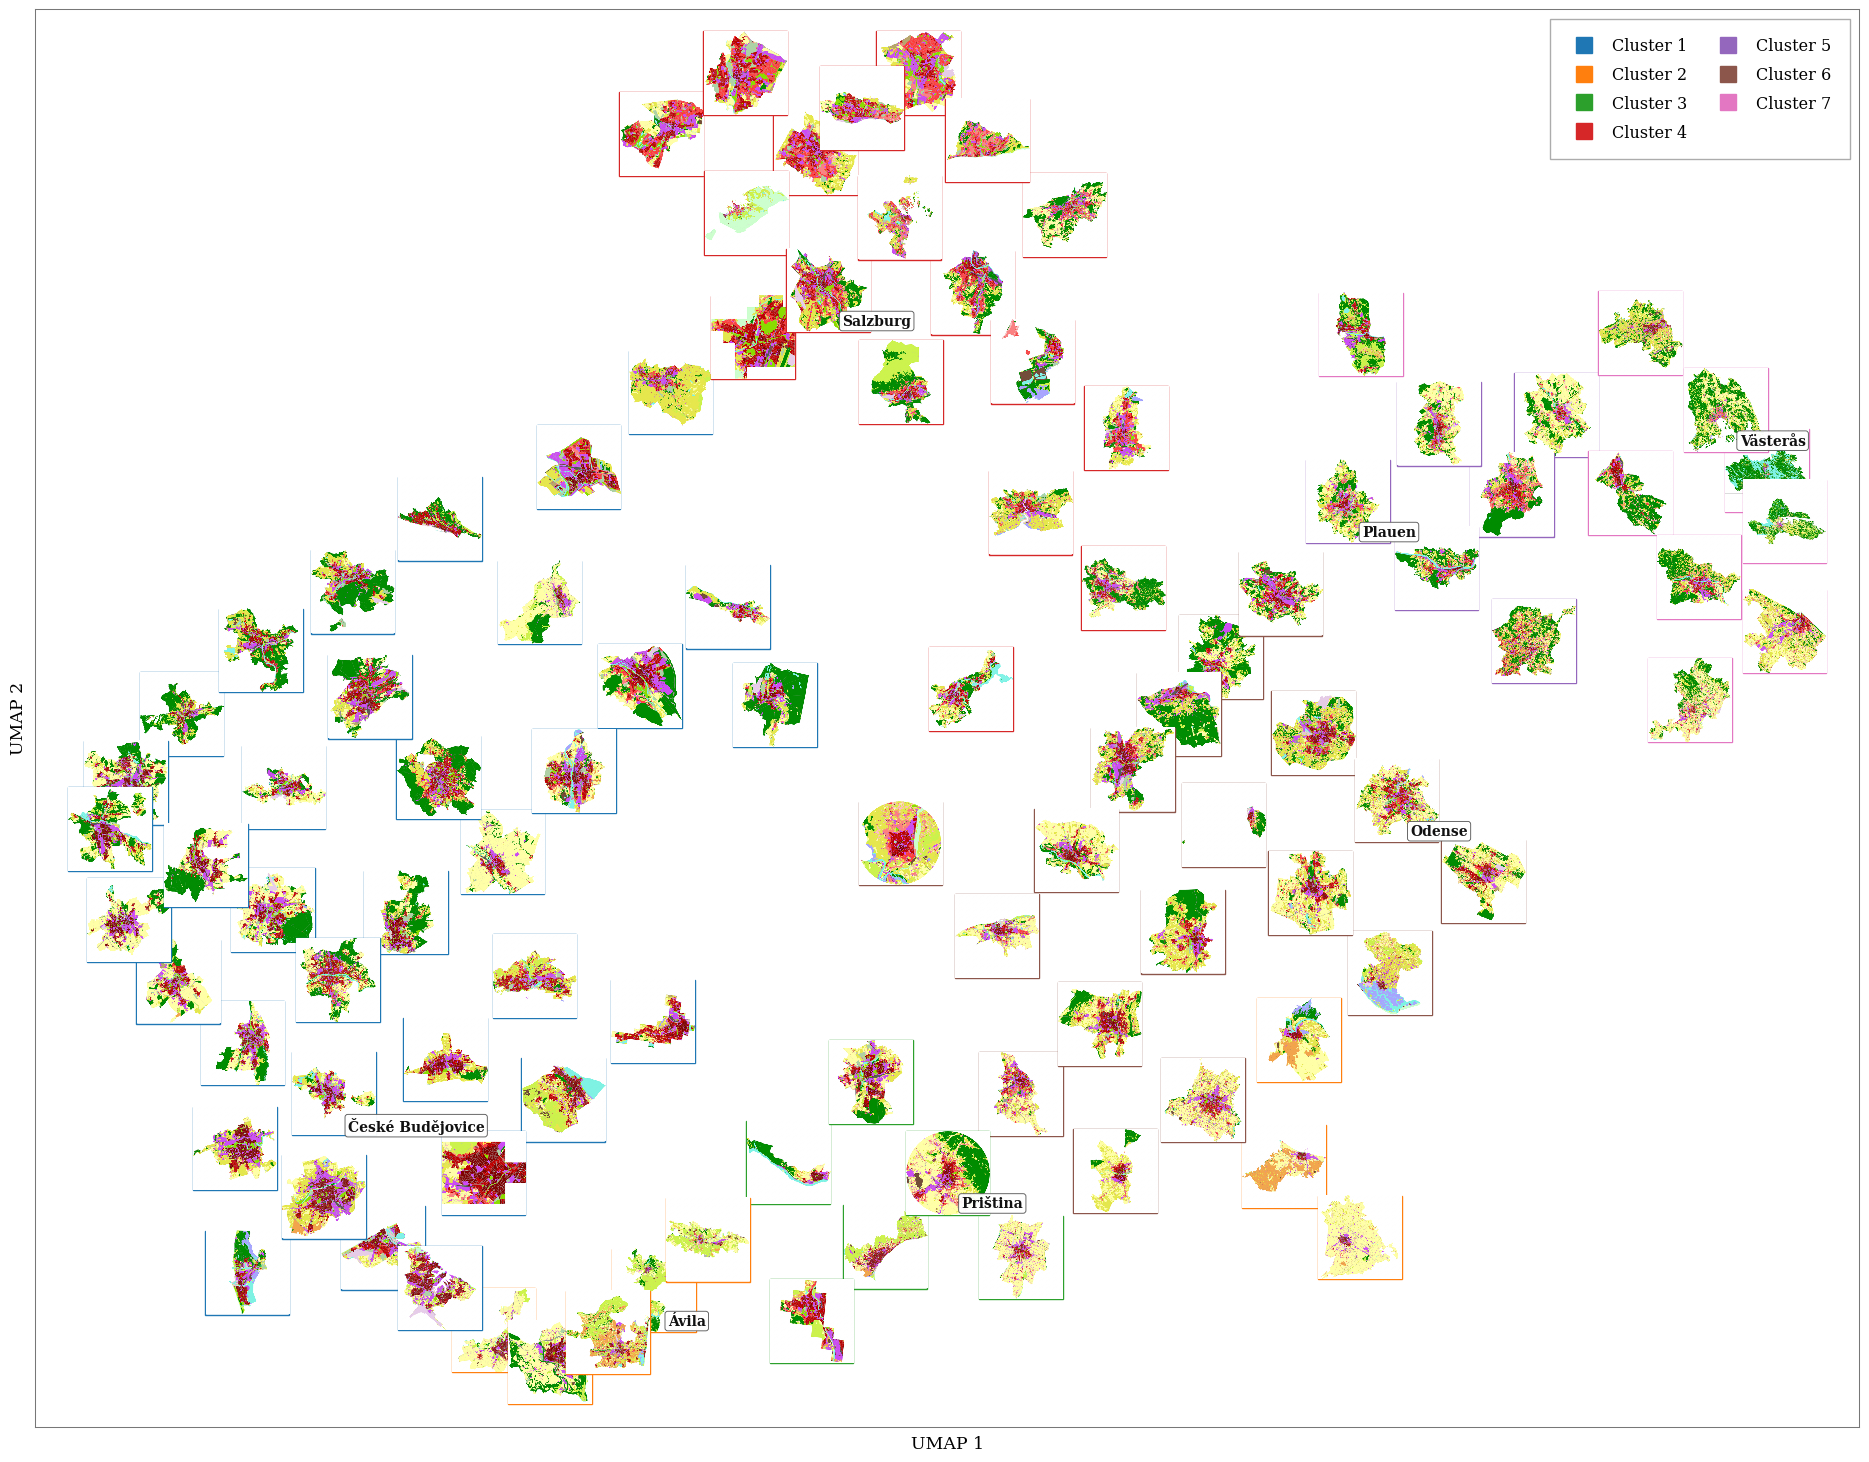


JPER FINAL IMAGE-BASED UMAP COMPLETE

Analytical cities : 100
City thumbnails   : 100
Exact features    : 1543

Final cluster sizes:
cluster
1    35
2     8
3     6
4    18
5     6
6    18
7     9
Name: count, dtype: int64

Medoids:
  Cluster 1: České Budějovice
  Cluster 2: Ávila
  Cluster 3: Priština
  Cluster 4: Salzburg
  Cluster 5: Plauen
  Cluster 6: Odense
  Cluster 7: Västerås

Final visualization settings:
  ZOOM              : 0.2
  UMAP neighbors    : 15
  UMAP min_dist     : 0.1
  UMAP metric       : euclidean
  UMAP seed         : 42
  x plot padding    : 2.5%
  y plot padding    : 3.0%

Files created:
  PNG: c:\Users\it08d\OneDrive - kcg.ac.jp\Downloads\JPER_v3_Notebook_Patch\JPER_revision_outputs_v3\umap_image_scatter_all100_final.png
  PDF: c:\Users\it08d\OneDrive - kcg.ac.jp\Downloads\JPER_v3_Notebook_Patch\JPER_revision_outputs_v3\umap_image_scatter_all100_final.pdf
  Exact coordinates: c:\Users\it08d\OneDrive - kcg.ac.jp\Downloads\JPER_v3_Notebook_Patch\JPER_revisio

In [2]:
# ======================================================================
# OPTIONAL: IMAGE-BASED MANUSCRIPT UMAP WITH ALL 100 CITY THUMBNAILS
# ======================================================================
#
# This final visualization requires a cities/ directory containing the
# city-map images. It is NOT required for the analytical reproduction.
# If cities/ is absent, Run All skips this cell without an error.
#
# The embedded output below is retained from the authors' final run.
# ======================================================================

FIGURES_DIR_AVAILABLE = (PROJECT_DIR / "cities").is_dir()
if not FIGURES_DIR_AVAILABLE:
    print(
        "Optional thumbnail UMAP skipped: cities/ was not found. "
        "All analytical results and standard UMAP diagnostics are already complete."
    )
else:
    # ======================================================================
    # JPER v3 — FINAL IMAGE-BASED UMAP WITH ALL 100 CITY THUMBNAILS
    # ======================================================================
    #
    # Uses:
    #   JPER_outputs_v3/city_itemset_exact_support_10pct.csv.gz
    #   JPER_outputs_v3/primary_cluster_assignments.csv
    #   cities/<city images>
    #
    # Analytical configuration:
    #   100 cities
    #   1,543 exact-support features
    #   L2 row normalization
    #   fixed original-space Ward cluster assignments
    #
    # This cell recreates ONLY the manuscript display UMAP:
    #   n_neighbors = 15
    #   min_dist     = 0.1
    #   metric       = euclidean
    #   random_state = 42
    #
    # It DOES NOT rerun:
    #   negFIN
    #   clustering
    #   k selection
    #   feature stability
    #   support-threshold sensitivity
    #   representation sensitivity
    #   54-run UMAP diagnostics
    # ======================================================================


    from pathlib import Path
    from collections import defaultdict
    import difflib
    import re
    import unicodedata
    import warnings

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    from matplotlib.offsetbox import OffsetImage, AnnotationBbox
    from matplotlib.lines import Line2D

    from PIL import Image

    from sklearn.preprocessing import normalize
    from scipy.spatial.distance import pdist, squareform

    import umap

    warnings.filterwarnings("ignore")


    # ======================================================================
    # 1. PROJECT PATHS
    # ======================================================================

    BASE_DIR = PROJECT_DIR

    RESULTS_DIR = OUTPUT_DIR if (OUTPUT_DIR / "city_itemset_exact_support_10pct.csv.gz").exists() else REFERENCE_OUTPUT_DIR
    IMG_DIR = BASE_DIR / "cities"

    SUPPORT_FILE = RESULTS_DIR / "city_itemset_exact_support_10pct.csv.gz"
    CLUSTER_FILE = RESULTS_DIR / "primary_cluster_assignments.csv"

    OUT_STEM = RESULTS_DIR / "umap_image_scatter_all100_final"

    print("Project directory :", BASE_DIR)
    print("Results directory :", RESULTS_DIR)
    print("Image directory   :", IMG_DIR)
    print()

    for path in [
        RESULTS_DIR,
        IMG_DIR,
        SUPPORT_FILE,
        CLUSTER_FILE,
    ]:
        if not path.exists():
            raise FileNotFoundError(
                f"Required path not found:\n{path}"
            )

    print("✓ Required project files found.")


    # ======================================================================
    # 2. FINAL FIGURE SETTINGS
    # ======================================================================

    # Large canvas for publication rendering
    FIGSIZE = (19, 15)

    # High-resolution PNG
    DPI = 600

    # ----------------------------------------------------------------------
    # Thumbnail appearance
    # ----------------------------------------------------------------------
    # User-selected final size
    ZOOM = 0.20

    THUMBNAIL_PIXELS = 300
    THUMB_BORDER_WIDTH = 1.0

    # ----------------------------------------------------------------------
    # Figure content
    # ----------------------------------------------------------------------
    # False = do not show pale anchor dots behind thumbnails
    SHOW_ALL_100_POINTS = False

    # Label only the seven medoid cities
    LABEL_MEDOIDS = True

    # Keep False for manuscript figure
    LABEL_ALL_THUMBNAIL_CITIES = False

    # Mild displacement prevents severe image overlap
    USE_OVERLAP_RELAXATION = True

    # Keep False for the clean main-paper version
    SHOW_CONNECTOR_LINES = False

    # Caption will explain the figure, so no internal title
    SHOW_TITLE = False

    SHOW_AXIS_LABELS = True
    SHOW_TICKS = False


    # ======================================================================
    # 3. FINAL V3 EXPECTATIONS
    # ======================================================================

    EXPECTED_N_CITIES = 100
    EXPECTED_N_FEATURES = 1543

    EXPECTED_CLUSTER_SIZES = {
        1: 35,
        2: 8,
        3: 6,
        4: 18,
        5: 6,
        6: 18,
        7: 9,
    }

    EXPECTED_MEDOIDS = {
        1: "CESKE_BUDEJOVICE",
        2: "AVILA",
        3: "PRISTINA",
        4: "SALZBURG",
        5: "PLAUEN",
        6: "ODENSE",
        7: "VASTERAS",
    }


    # ======================================================================
    # 4. CLUSTER COLORS
    # ======================================================================

    CLUSTER_COLORS = {
        1: "#1f77b4",
        2: "#ff7f0e",
        3: "#2ca02c",
        4: "#d62728",
        5: "#9467bd",
        6: "#8c564b",
        7: "#e377c2",
    }


    # ======================================================================
    # 5. PRETTY DISPLAY NAMES
    # ======================================================================

    PRETTY_NAME_OVERRIDES = {
        "AVILA": "Ávila",
        "BANSKA_BYSTRICA": "Banská Bystrica",
        "CESKE_BUDEJOVICE": "České Budějovice",
        "CHALONS_EN_CHAMPAGNE": "Châlons-en-Champagne",
        "DROBETA_TURNU_SEVERIN": "Drobeta-Turnu Severin",
        "HRADEC_KRALOVE": "Hradec Králové",
        "KARLOVY_VARY": "Karlovy Vary",
        "NYIREGYHAZA": "Nyíregyháza",
        "NORRKOPING": "Norrköping",
        "PANEVEZYS": "Panevėžys",
        "PLZEN": "Plzeň",
        "PRESOV": "Prešov",
        "PRISTINA": "Priština",
        "USTI_NAD_LABEM": "Ústí nad Labem",
        "VASTERAS": "Västerås",
        "ZILINA": "Žilina",
    }


    # ======================================================================
    # 6. NORMALIZE CITY NAMES / IMAGE FILENAMES
    # ======================================================================

    def normalize_city_key(value):
        """
        Normalize analysis city names and image filenames.

        Old prefixes such as:
            g1_city.jpg
            g2_city.png
            g7_city.jpg

        are removed automatically.
        """

        text = Path(str(value)).stem

        # Remove old g1_, g2_, ... prefix if present
        text = re.sub(
            r"^g\d+[_\-\s]+",
            "",
            text,
            flags=re.IGNORECASE,
        )

        # Normalize accented characters for filename matching
        text = unicodedata.normalize(
            "NFKD",
            text,
        )

        text = "".join(
            c for c in text
            if not unicodedata.combining(c)
        )

        text = text.upper()

        text = re.sub(
            r"[^A-Z0-9]+",
            "_",
            text,
        )

        text = re.sub(
            r"_+",
            "_",
            text,
        ).strip("_")

        return text


    def pretty_city_name(city_key):

        if city_key in PRETTY_NAME_OVERRIDES:
            return PRETTY_NAME_OVERRIDES[city_key]

        small_words = {
            "DE",
            "LA",
            "LE",
            "EN",
            "NAD",
            "AM",
            "OF",
            "AND",
        }

        output = []

        for token in city_key.split("_"):

            if token in small_words:
                output.append(token.lower())
            else:
                output.append(token.capitalize())

        return " ".join(output)


    # ======================================================================
    # 7. READ EXACT V3 SUPPORT MATRIX
    # ======================================================================

    print("\nReading exact-support matrix...")

    support_df = pd.read_csv(
        SUPPORT_FILE,
        index_col=0,
    )

    support_df.index = (
        support_df.index.astype(str)
    )

    support_df = support_df.apply(
        pd.to_numeric,
        errors="raise",
    )

    print(
        "Exact-support matrix shape:",
        support_df.shape
    )

    if support_df.shape != (
        EXPECTED_N_CITIES,
        EXPECTED_N_FEATURES,
    ):
        raise AssertionError(
            "Unexpected support matrix shape.\n"
            f"Expected: "
            f"({EXPECTED_N_CITIES}, {EXPECTED_N_FEATURES})\n"
            f"Observed: {support_df.shape}"
        )

    print(
        "✓ 100 × 1,543 exact-support matrix verified."
    )


    # ======================================================================
    # 8. READ FINAL V3 CLUSTER ASSIGNMENTS
    # ======================================================================

    cluster_df = pd.read_csv(
        CLUSTER_FILE
    )

    if not {
        "city",
        "cluster",
    }.issubset(
        cluster_df.columns
    ):
        raise ValueError(
            "primary_cluster_assignments.csv must "
            "contain 'city' and 'cluster' columns."
        )


    cluster_lookup = cluster_df[
        [
            "city",
            "cluster",
        ]
    ].copy()

    cluster_lookup[
        "city_key"
    ] = cluster_lookup[
        "city"
    ].map(
        normalize_city_key
    )

    cluster_lookup[
        "cluster"
    ] = cluster_lookup[
        "cluster"
    ].astype(int)


    if cluster_lookup[
        "city_key"
    ].duplicated().any():

        duplicates = cluster_lookup.loc[
            cluster_lookup[
                "city_key"
            ].duplicated(False),
            "city_key",
        ].tolist()

        raise AssertionError(
            "Duplicate normalized city keys "
            f"in cluster file:\n{duplicates}"
        )


    cluster_lookup = (
        cluster_lookup
        .set_index("city_key")
    )


    # ======================================================================
    # 9. MASTER 100-CITY TABLE
    # ======================================================================

    main_df = pd.DataFrame({
        "city": support_df.index
    })

    main_df[
        "city_key"
    ] = main_df[
        "city"
    ].map(
        normalize_city_key
    )


    missing_cluster_keys = sorted(
        set(main_df["city_key"])
        - set(cluster_lookup.index)
    )

    if missing_cluster_keys:
        raise AssertionError(
            "Missing final cluster assignments for:\n"
            + "\n".join(missing_cluster_keys)
        )


    main_df[
        "cluster"
    ] = cluster_lookup.loc[
        main_df["city_key"],
        "cluster",
    ].to_numpy()

    main_df[
        "cluster"
    ] = main_df[
        "cluster"
    ].astype(int)

    main_df[
        "pretty_city"
    ] = main_df[
        "city_key"
    ].map(
        pretty_city_name
    )


    # ======================================================================
    # 10. VERIFY FINAL CLUSTER SIZES
    # ======================================================================

    observed_sizes = (
        main_df[
            "cluster"
        ]
        .value_counts()
        .sort_index()
        .to_dict()
    )

    print(
        "\nFinal cluster sizes:",
        observed_sizes
    )

    if observed_sizes != EXPECTED_CLUSTER_SIZES:
        raise AssertionError(
            "Cluster sizes differ from "
            "the final v3 solution.\n"
            f"Expected: {EXPECTED_CLUSTER_SIZES}\n"
            f"Observed: {observed_sizes}"
        )

    print(
        "✓ Final v3 cluster assignments verified."
    )


    # ======================================================================
    # 11. L2-NORMALIZE EXACT SUPPORT MATRIX
    # ======================================================================

    X_exact = support_df.to_numpy(
        dtype=np.float64
    )

    X_norm = normalize(
        X_exact,
        norm="l2",
        axis=1,
    )


    row_norms = np.linalg.norm(
        X_norm,
        axis=1,
    )

    if not np.allclose(
        row_norms,
        1.0,
        atol=1e-12,
    ):
        raise AssertionError(
            "L2 normalization check failed."
        )

    print(
        "✓ L2 normalization verified."
    )


    # ======================================================================
    # 12. COMPUTE CLUSTER MEDOIDS
    # ======================================================================

    def compute_medoids(
        X,
        labels,
        city_keys,
    ):

        labels = np.asarray(labels)
        city_keys = np.asarray(city_keys)

        result = {}

        for cluster_id in sorted(
            np.unique(labels)
        ):

            positions = np.where(
                labels == cluster_id
            )[0]

            within = squareform(
                pdist(
                    X[positions],
                    metric="euclidean",
                )
            )

            medoid_position = positions[
                np.argmin(
                    within.sum(axis=1)
                )
            ]

            result[
                int(cluster_id)
            ] = city_keys[
                medoid_position
            ]

        return result


    medoid_map = compute_medoids(
        X_norm,
        main_df[
            "cluster"
        ].to_numpy(),
        main_df[
            "city_key"
        ].to_numpy(),
    )


    print(
        "\nMedoids:"
    )

    for cluster_id in sorted(
        medoid_map
    ):
        print(
            f"Cluster {cluster_id}: "
            f"{pretty_city_name(medoid_map[cluster_id])}"
        )


    if medoid_map != EXPECTED_MEDOIDS:
        raise AssertionError(
            "Computed medoids differ from "
            "the expected final v3 medoids.\n"
            f"Expected: {EXPECTED_MEDOIDS}\n"
            f"Observed: {medoid_map}"
        )

    print(
        "✓ Final v3 medoids verified."
    )


    # ======================================================================
    # 13. RECREATE ONLY THE MANUSCRIPT DISPLAY UMAP
    # ======================================================================

    print(
        "\nCreating manuscript display UMAP only..."
    )

    print(
        "n_neighbors=15, "
        "min_dist=0.1, "
        "metric=euclidean, "
        "seed=42"
    )


    display_model = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=2,
        metric="euclidean",
        random_state=42,
        n_jobs=1,
        low_memory=True,
    )


    display_embedding = (
        display_model.fit_transform(
            X_norm
        )
    )


    if display_embedding.shape != (
        100,
        2,
    ):
        raise AssertionError(
            "Unexpected UMAP shape: "
            f"{display_embedding.shape}"
        )


    main_df[
        "UMAP1"
    ] = display_embedding[:, 0]

    main_df[
        "UMAP2"
    ] = display_embedding[:, 1]


    coordinate_file = (
        RESULTS_DIR
        / "umap_city_coordinates_seed42.csv"
    )

    main_df[
        [
            "city",
            "city_key",
            "pretty_city",
            "cluster",
            "UMAP1",
            "UMAP2",
        ]
    ].to_csv(
        coordinate_file,
        index=False,
    )

    print(
        "✓ Exact UMAP coordinates saved:",
        coordinate_file
    )


    # ======================================================================
    # 14. FIND ALL 100 CITY IMAGES
    # ======================================================================

    ALLOWED_EXTENSIONS = {
        ".jpg",
        ".jpeg",
        ".png",
        ".webp",
        ".tif",
        ".tiff",
    }


    analytical_city_keys = set(
        main_df[
            "city_key"
        ]
    )


    image_candidates = defaultdict(
        list
    )


    for image_path in (
        IMG_DIR.iterdir()
    ):

        if not image_path.is_file():
            continue

        if (
            image_path.suffix.lower()
            not in ALLOWED_EXTENSIONS
        ):
            continue

        key = normalize_city_key(
            image_path.name
        )

        # Ignore non-analysis figures
        if key not in analytical_city_keys:
            continue

        image_candidates[
            key
        ].append(
            image_path
        )


    # ======================================================================
    # 15. IF DUPLICATE CITY IMAGES EXIST, USE THE LARGEST FILE
    # ======================================================================

    image_map = {}

    for key, paths in (
        image_candidates.items()
    ):

        paths = sorted(
            paths,
            key=lambda p: p.stat().st_size,
            reverse=True,
        )

        image_map[
            key
        ] = paths[0]

        if len(paths) > 1:
            print(
                f"NOTE: multiple images matched "
                f"{key}; using {paths[0].name}"
            )


    # ======================================================================
    # 16. VERIFY ALL 100 CITY IMAGES
    # ======================================================================

    main_df[
        "image_path"
    ] = main_df[
        "city_key"
    ].map(
        image_map
    )


    missing_images = (
        main_df.loc[
            main_df[
                "image_path"
            ].isna()
        ]
        .copy()
    )


    print(
        "\n--- IMAGE CHECK ---"
    )

    print(
        "Analytical cities :",
        len(main_df)
    )

    print(
        "Images matched    :",
        main_df[
            "image_path"
        ].notna().sum()
    )

    print(
        "Images missing    :",
        len(missing_images)
    )


    if len(
        missing_images
    ) > 0:

        available_keys = list(
            image_map.keys()
        )

        for row in (
            missing_images
            .itertuples(
                index=False
            )
        ):

            suggestions = (
                difflib
                .get_close_matches(
                    row.city_key,
                    available_keys,
                    n=3,
                    cutoff=0.50,
                )
            )

            print(
                f"\nMissing image for "
                f"{row.city} "
                f"({row.city_key})"
            )

            if suggestions:
                print(
                    "Possible matches:",
                    suggestions
                )

        raise RuntimeError(
            "\nThe figure was NOT generated because "
            "one or more analytical cities has no "
            "matching image."
        )


    print(
        "✓ All 100 city images matched."
    )


    # ======================================================================
    # 17. CREATE SQUARE THUMBNAILS
    # ======================================================================

    def create_square_thumbnail(
        image_path,
        target_px=300,
        bg_tol=10,
        crop_pad=8,
    ):
        """
        Create a square thumbnail while preserving city-map aspect ratio.

        For circular-source images:
          - detect surrounding background,
          - crop unnecessary outer background,
          - retain the circular map itself,
          - place it on a square white canvas.

        No missing map content is invented.
        """

        with Image.open(
            image_path
        ) as original:

            img = original.convert(
                "RGB"
            )

            arr = np.asarray(
                img
            ).astype(
                np.uint8
            )


        h, w, _ = arr.shape

        corner_size = max(
            8,
            min(h, w) // 20,
        )


        corner_pixels = np.concatenate(
            [
                arr[
                    :corner_size,
                    :corner_size,
                    :
                ].reshape(-1, 3),

                arr[
                    :corner_size,
                    -corner_size:,
                    :
                ].reshape(-1, 3),

                arr[
                    -corner_size:,
                    :corner_size,
                    :
                ].reshape(-1, 3),

                arr[
                    -corner_size:,
                    -corner_size:,
                    :
                ].reshape(-1, 3),
            ],
            axis=0,
        ).astype(
            np.float32
        )


        background = np.median(
            corner_pixels,
            axis=0,
        )


        distance_from_background = np.sqrt(
            (
                (
                    arr.astype(
                        np.float32
                    )
                    - background
                ) ** 2
            ).sum(
                axis=2
            )
        )


        mask = (
            distance_from_background
            > bg_tol
        )


        if mask.any():

            ys, xs = np.where(
                mask
            )

            y0 = max(
                0,
                ys.min()
                - crop_pad
            )

            y1 = min(
                h,
                ys.max()
                + 1
                + crop_pad
            )

            x0 = max(
                0,
                xs.min()
                - crop_pad
            )

            x1 = min(
                w,
                xs.max()
                + 1
                + crop_pad
            )

            cropped = Image.fromarray(
                arr[
                    y0:y1,
                    x0:x1
                ]
            )

        else:

            cropped = Image.fromarray(
                arr
            )


        cropped.thumbnail(
            (
                target_px,
                target_px,
            ),
            Image.LANCZOS,
        )


        canvas = Image.new(
            "RGB",
            (
                target_px,
                target_px,
            ),
            "white",
        )


        x_offset = (
            target_px
            - cropped.width
        ) // 2

        y_offset = (
            target_px
            - cropped.height
        ) // 2


        canvas.paste(
            cropped,
            (
                x_offset,
                y_offset,
            )
        )


        return np.asarray(
            canvas
        )


    thumbnail_cache = {}


    for row in (
        main_df.itertuples(
            index=False
        )
    ):

        thumbnail_cache[
            row.city_key
        ] = create_square_thumbnail(
            row.image_path,
            target_px=THUMBNAIL_PIXELS,
        )


    print(
        "✓ 100 square thumbnails prepared."
    )


    # ======================================================================
    # 18. COLLISION REDUCTION
    # ======================================================================
    #
    # ZOOM = 0.20 is intentionally large.
    # These settings retain the geometry while gently separating
    # severe thumbnail collisions.
    # ======================================================================

    def relax_positions(
        exact_xy,
        collision_width=0.060,
        collision_height=0.070,
        steps=500,
        repulsion=0.030,
        spring=0.016,
        margin=0.018,
        seed=42,
    ):
        """
        Reduce thumbnail overlap while retaining proximity
        to the exact UMAP coordinates.

        UMAP1 / UMAP2 remain untouched.
        x_plot / y_plot are visualization positions only.
        """

        exact_xy = np.asarray(
            exact_xy,
            dtype=float,
        )


        mins = exact_xy.min(
            axis=0
        )

        maxs = exact_xy.max(
            axis=0
        )

        spans = (
            maxs
            - mins
        )

        spans[
            spans == 0
        ] = 1.0


        anchors = (
            exact_xy
            - mins
        ) / spans


        positions = (
            anchors.copy()
        )


        rng = np.random.default_rng(
            seed
        )


        positions += rng.normal(
            0,
            1e-5,
            positions.shape,
        )


        n = len(
            positions
        )


        for _ in range(
            steps
        ):

            forces = np.zeros_like(
                positions
            )


            for i in range(
                n - 1
            ):

                for j in range(
                    i + 1,
                    n
                ):

                    dx = (
                        positions[
                            j,
                            0
                        ]
                        - positions[
                            i,
                            0
                        ]
                    )

                    dy = (
                        positions[
                            j,
                            1
                        ]
                        - positions[
                            i,
                            1
                        ]
                    )


                    overlap_x = (
                        collision_width
                        - abs(dx)
                    )

                    overlap_y = (
                        collision_height
                        - abs(dy)
                    )


                    if (
                        overlap_x > 0
                        and overlap_y > 0
                    ):

                        if abs(dx) < 1e-8:
                            dx = (
                                rng.choice(
                                    [-1, 1]
                                )
                                * 1e-4
                            )

                        if abs(dy) < 1e-8:
                            dy = (
                                rng.choice(
                                    [-1, 1]
                                )
                                * 1e-4
                            )


                        push_x = (
                            np.sign(dx)
                            * overlap_x
                            * repulsion
                        )

                        push_y = (
                            np.sign(dy)
                            * overlap_y
                            * repulsion
                        )


                        forces[
                            i,
                            0
                        ] -= push_x

                        forces[
                            j,
                            0
                        ] += push_x

                        forces[
                            i,
                            1
                        ] -= push_y

                        forces[
                            j,
                            1
                        ] += push_y


            # Spring back toward exact UMAP anchors
            forces += (
                anchors
                - positions
            ) * spring


            positions += forces


            positions[
                :,
                0
            ] = np.clip(
                positions[
                    :,
                    0
                ],
                margin,
                1 - margin,
            )


            positions[
                :,
                1
            ] = np.clip(
                positions[
                    :,
                    1
                ],
                margin,
                1 - margin,
            )


        return (
            positions
            * spans
            + mins
        )


    exact_xy = main_df[
        [
            "UMAP1",
            "UMAP2",
        ]
    ].to_numpy()


    if USE_OVERLAP_RELAXATION:

        display_xy = relax_positions(
            exact_xy
        )

    else:

        display_xy = (
            exact_xy.copy()
        )


    main_df[
        "x_plot"
    ] = display_xy[:, 0]

    main_df[
        "y_plot"
    ] = display_xy[:, 1]


    # ======================================================================
    # 19. SAVE THUMBNAIL LAYOUT
    # ======================================================================

    layout_file = (
        RESULTS_DIR
        / "umap_all100_thumbnail_layout_final.csv"
    )


    layout_df = main_df[
        [
            "city",
            "city_key",
            "pretty_city",
            "cluster",
            "UMAP1",
            "UMAP2",
            "x_plot",
            "y_plot",
            "image_path",
        ]
    ].copy()


    layout_df[
        "image_path"
    ] = layout_df[
        "image_path"
    ].astype(str)


    layout_df.to_csv(
        layout_file,
        index=False,
    )


    print(
        "✓ Thumbnail layout saved:",
        layout_file
    )


    # ======================================================================
    # 20. CREATE FINAL PUBLICATION FIGURE
    # ======================================================================

    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "dejavuserif",
        "axes.linewidth": 0.75,
    })


    fig, ax = plt.subplots(
        figsize=FIGSIZE
    )


    fig.patch.set_facecolor(
        "white"
    )

    ax.set_facecolor(
        "white"
    )


    # ======================================================================
    # 21. OPTIONAL EXACT POINTS
    # ======================================================================

    if SHOW_ALL_100_POINTS:

        for cluster_id in range(
            1,
            8
        ):

            sub = main_df.loc[
                main_df[
                    "cluster"
                ] == cluster_id
            ]

            ax.scatter(
                sub["UMAP1"],
                sub["UMAP2"],
                s=18,
                color=CLUSTER_COLORS[
                    cluster_id
                ],
                alpha=0.20,
                linewidths=0,
                zorder=1,
            )


    # ======================================================================
    # 22. OPTIONAL CONNECTORS
    # ======================================================================

    if (
        SHOW_CONNECTOR_LINES
        and USE_OVERLAP_RELAXATION
    ):

        for row in (
            main_df.itertuples(
                index=False
            )
        ):

            displacement = np.hypot(
                row.x_plot
                - row.UMAP1,

                row.y_plot
                - row.UMAP2,
            )


            if displacement > 0.025:

                ax.plot(
                    [
                        row.UMAP1,
                        row.x_plot,
                    ],
                    [
                        row.UMAP2,
                        row.y_plot,
                    ],
                    color=CLUSTER_COLORS[
                        int(
                            row.cluster
                        )
                    ],
                    linewidth=0.45,
                    alpha=0.25,
                    zorder=2,
                )


    # ======================================================================
    # 23. OVERLAY ALL 100 CITY THUMBNAILS
    # ======================================================================

    for row in (
        main_df.itertuples(
            index=False
        )
    ):

        image_box = OffsetImage(
            thumbnail_cache[
                row.city_key
            ],
            zoom=ZOOM,
            interpolation="lanczos",
        )


        city_box = AnnotationBbox(
            image_box,
            (
                row.x_plot,
                row.y_plot,
            ),
            frameon=True,
            pad=0.014,
            zorder=4,
            bboxprops=dict(
                edgecolor=CLUSTER_COLORS[
                    int(
                        row.cluster
                    )
                ],
                linewidth=THUMB_BORDER_WIDTH,
                facecolor="white",
            ),
        )


        ax.add_artist(
            city_box
        )


    # ======================================================================
    # 24. LABEL ONLY THE SEVEN MEDOIDS
    # ======================================================================

    if LABEL_MEDOIDS:

        # Individually tuned offsets to avoid covering thumbnails.
        MEDOID_OFFSETS = {
            1: (10, -17),    # České Budějovice
            2: (10, -17),    # Ávila
            3: (10, -17),    # Priština
            4: (10, -17),    # Salzburg
            5: (10, -17),    # Plauen
            6: (10, -17),    # Odense
            7: (10, -17),    # Västerås
        }


        for (
            cluster_id,
            medoid_key
        ) in medoid_map.items():


            row = main_df.loc[
                main_df[
                    "city_key"
                ] == medoid_key
            ]


            if row.empty:
                continue


            row = row.iloc[0]


            dx, dy = MEDOID_OFFSETS.get(
                cluster_id,
                (10, -17),
            )


            ax.annotate(
                pretty_city_name(
                    medoid_key
                ),
                xy=(
                    row[
                        "x_plot"
                    ],
                    row[
                        "y_plot"
                    ],
                ),
                xytext=(
                    dx,
                    dy,
                ),
                textcoords="offset points",
                fontsize=10.0,
                fontweight="bold",
                color="#111111",
                ha="left",
                va="top",
                bbox=dict(
                    boxstyle="round,pad=0.20",
                    facecolor="white",
                    edgecolor="#555555",
                    linewidth=0.65,
                    alpha=0.96,
                ),
                zorder=8,
            )


    # ======================================================================
    # 25. OPTIONAL ALL-CITY LABELS
    # ======================================================================

    if LABEL_ALL_THUMBNAIL_CITIES:

        for row in (
            main_df.itertuples(
                index=False
            )
        ):

            ax.annotate(
                row.pretty_city,
                xy=(
                    row.x_plot,
                    row.y_plot,
                ),
                xytext=(
                    5,
                    5,
                ),
                textcoords="offset points",
                fontsize=5.5,
                color="#222222",
                bbox=dict(
                    boxstyle="round,pad=0.10",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.75,
                ),
                zorder=7,
            )


    # ======================================================================
    # 26. LARGE FINAL LEGEND
    # ======================================================================

    legend_handles = []


    for cluster_id in range(
        1,
        8
    ):

        legend_handles.append(

            Line2D(
                [0],
                [0],
                marker="s",
                linestyle="None",

                # Larger colored squares
                markersize=12,

                markerfacecolor=CLUSTER_COLORS[
                    cluster_id
                ],

                markeredgecolor=CLUSTER_COLORS[
                    cluster_id
                ],

                label=f"Cluster {cluster_id}",
            )

        )


    ax.legend(
        handles=legend_handles,

        loc="upper right",

        ncol=2,

        # Larger legend text
        fontsize=11.5,

        frameon=True,
        framealpha=0.97,

        # Larger internal box padding
        borderpad=1.15,

        # Vertical spacing between rows
        labelspacing=0.75,

        # Space between square and text
        handletextpad=0.75,

        # Space between the two columns
        columnspacing=1.55,

        # Small distance from axes border
        borderaxespad=0.60,

        fancybox=False,

        edgecolor="#AAAAAA",
    )


    # ======================================================================
    # 27. TIGHTER DATA MARGINS
    # ======================================================================

    all_x = np.concatenate(
        [
            main_df[
                "UMAP1"
            ].to_numpy(),

            main_df[
                "x_plot"
            ].to_numpy(),
        ]
    )


    all_y = np.concatenate(
        [
            main_df[
                "UMAP2"
            ].to_numpy(),

            main_df[
                "y_plot"
            ].to_numpy(),
        ]
    )


    xmin = all_x.min()
    xmax = all_x.max()

    ymin = all_y.min()
    ymax = all_y.max()


    # ----------------------------------------------------------------------
    # Reduced white space compared with previous 0.08 setting
    # ----------------------------------------------------------------------
    #
    # Do not make these exactly zero because large ZOOM=0.20 thumbnails
    # need a little room at the boundaries.
    #
    # ----------------------------------------------------------------------

    x_pad = (
        xmax - xmin
    ) * 0.025

    y_pad = (
        ymax - ymin
    ) * 0.030


    ax.set_xlim(
        xmin - x_pad,
        xmax + x_pad,
    )


    ax.set_ylim(
        ymin - y_pad,
        ymax + y_pad,
    )


    # ======================================================================
    # 28. AXIS STYLE
    # ======================================================================

    if SHOW_TITLE:

        ax.set_title(
            "Image-based UMAP visualization "
            "of the fixed original-space clusters",
            fontsize=15,
            pad=12,
        )


    if SHOW_AXIS_LABELS:

        ax.set_xlabel(
            "UMAP 1",
            fontsize=12.5,
            labelpad=6,
        )

        ax.set_ylabel(
            "UMAP 2",
            fontsize=12.5,
            labelpad=6,
        )


    if not SHOW_TICKS:

        ax.set_xticks([])
        ax.set_yticks([])


    ax.grid(False)


    for spine in (
        ax.spines.values()
    ):

        spine.set_color(
            "#777777"
        )

        spine.set_linewidth(
            0.75
        )


    # ======================================================================
    # 29. REDUCE OUTER CANVAS MARGINS
    # ======================================================================
    #
    # Do NOT use fig.tight_layout() here.
    #
    # These values allow the UMAP to occupy almost the full canvas while
    # leaving enough space for axis labels.
    # ======================================================================

    fig.subplots_adjust(
        left=0.035,
        right=0.995,
        bottom=0.050,
        top=0.995,
    )


    # ======================================================================
    # 30. SAVE FINAL OUTPUTS
    # ======================================================================

    PNG_FILE = Path(
        str(OUT_STEM)
        + ".png"
    )


    PDF_FILE = Path(
        str(OUT_STEM)
        + ".pdf"
    )


    fig.savefig(
        PNG_FILE,
        dpi=DPI,

        # Crop remaining outer whitespace
        bbox_inches="tight",

        # Very small additional file-level padding
        pad_inches=0.02,

        facecolor="white",
    )


    fig.savefig(
        PDF_FILE,
        bbox_inches="tight",
        pad_inches=0.02,
        facecolor="white",
    )


    plt.show()
    plt.close(fig)


    # ======================================================================
    # 31. FINAL REPORT
    # ======================================================================

    print(
        "\n============================================"
    )

    print(
        "JPER FINAL IMAGE-BASED UMAP COMPLETE"
    )

    print(
        "============================================"
    )


    print(
        "\nAnalytical cities :",
        len(main_df)
    )

    print(
        "City thumbnails   :",
        len(main_df)
    )

    print(
        "Exact features    :",
        support_df.shape[1]
    )


    print(
        "\nFinal cluster sizes:"
    )

    print(
        main_df[
            "cluster"
        ]
        .value_counts()
        .sort_index()
    )


    print(
        "\nMedoids:"
    )

    for cluster_id in sorted(
        medoid_map
    ):

        print(
            f"  Cluster {cluster_id}: "
            f"{pretty_city_name(medoid_map[cluster_id])}"
        )


    print(
        "\nFinal visualization settings:"
    )

    print(
        "  ZOOM              :",
        ZOOM
    )

    print(
        "  UMAP neighbors    : 15"
    )

    print(
        "  UMAP min_dist     : 0.1"
    )

    print(
        "  UMAP metric       : euclidean"
    )

    print(
        "  UMAP seed         : 42"
    )

    print(
        "  x plot padding    : 2.5%"
    )

    print(
        "  y plot padding    : 3.0%"
    )


    print(
        "\nFiles created:"
    )

    print(
        "  PNG:",
        PNG_FILE
    )

    print(
        "  PDF:",
        PDF_FILE
    )

    print(
        "  Exact coordinates:",
        coordinate_file
    )

    print(
        "  Thumbnail layout:",
        layout_file
    )


    print(
        "\n✓ All 100 analytical cities retained."
    )

    print(
        "✓ All 100 city maps shown as thumbnails."
    )

    print(
        "✓ Final v3 cluster labels retained."
    )

    print(
        "✓ Only the display UMAP was recreated."
    )

    print(
        "✓ Larger legend applied."
    )

    print(
        "✓ Outer white margins reduced."
    )

    print(
        "✓ Final figure complete."
    )
